# Bays (2014) Figure 2 Equivalence

Model-only recreation (no human data). The Bays reference dataset is loaded from the shared cache at `experiments/cached_data/`, which is built once by the standalone script:

```
python -m experiments.bays_cache.build_bays_cache
```

The cache filename encodes every Bays generating parameter (omega, gamma_total, M, N_trials, seed). Notebooks read whichever cache matches the `M` they request. If a requested cache is missing, the loader raises a `FileNotFoundError` telling you exactly which builder command to run.

## Notebook structure

The two **main experiments** are at the top, each with its own one-cell experiment control:

1. **GP-to-Bays Fit** — fits one GP-side sampler family $(\lambda, \gamma, \sigma)$ to the cached Bays errors.
2. **Fixed-CV Sweep** — six $(\lambda, \gamma)$ fits, one at each CV value, against the same Bays cache. Gamma sampler only (CV is the Gamma-sampler's heterogeneity knob).

Each experiment has a control cell **immediately above** its core logic. Set `M` and `DISTRIBUTION` in that cell, run, save figures. The two experiments are independent — changing the control of one does not affect the other.

The remaining sections (single-subject sweep, GP-only 6-panel figure, GP-vs-Bays overlay, diagnostics, M-scaling probe) are kept for context but are downstream of the global configuration in Setup.


## Setup


### Imports


In [3]:
# Setup for the Notebook

import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import os
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter, NullLocator, FixedLocator
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq, least_squares
from scipy.stats import vonmises

# GP framework
from core.encoder.gaussian_process import generate_neuron_population
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes
from core.decoder.ml_decoder import decode, circular_error

# Bays cache loader — single source of truth for the comparison reference
from experiments.bays_cache import load_bays_cache, list_available_caches

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


### Circular Statistics


In [4]:
#Circular Statistics 

def circular_variance_bays(errors):
    """
    Squared circular SD (Fisher 1995, used by Bays 2014):
        σ² = −2 log |m̄₁|
    """
    R = np.abs(np.mean(np.exp(1j * errors)))
    return -2.0 * np.log(max(R, 1e-15))


## CHECK: KURTOSIS EQUATIONS

def circular_kurtosis_bays(errors):
    """
    Fisher (1995) circular kurtosis, as cited by Bays (2014):
        k = [ρ₂ cos(Arg m₂ − 2 Arg m₁) − ρ₁⁴] / (1 − ρ₁)²
    """
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_correction - rho1 ** 4) / (V ** 2)


def circular_moments(errors):
    """Returns corrected variance and kurtosis."""
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    # Kurtosis: Fisher (1995) with (1 − ρ₁)² denominator
    kurt = (rho2 * phase_correction - rho1 ** 4) / (V ** 2) if V > 1e-10 else 0.0
    # Variance: σ² = −2 log|m̄₁| (Fisher 1995 / Bays 2014)
    var_bays = -2.0 * np.log(max(rho1, 1e-15))
    return {'variance': var_bays, 'kurtosis': kurt, 'mean_resultant': float(rho1)}


def _estimate_von_mises_kappa(rho1):
    if rho1 < 1e-6: return 0.0
    if rho1 > 0.9999: return 700.0
    return brentq(lambda k: float(i1(k)/i0(k)) - rho1, 1e-4, 700.0)


def compute_deviation_from_normal(errors, n_bins=50):
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf}


### Von Mises KDE


In [5]:
def vonmises_kde(data, eval_points, kappa):
    """
    Circular KDE using von Mises kernels.

    Parameters
    ----------
    data : array-like, shape (n,)
        Sample of angles in [−π, π).
    eval_points : array-like, shape (m,)
        Points at which to evaluate the density.
    kappa : float
        Concentration parameter of the von Mises kernel.
        Higher κ → narrower kernel (less smoothing).
        κ ≈ 1/h² where h is the Gaussian bandwidth equivalent.

    Returns
    -------
    density : ndarray, shape (m,)
    """
    data = np.asarray(data)
    eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]  # (m, n)
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm  # (m, n)
    density = np.exp(logsumexp(log_kernels, axis=1) - np.log(n))
    return density


# Bandwidth mapping: κ ≈ 1/h² (h = Gaussian bandwidth equivalent)
KAPPA_PANELS_AC = 25.0   # replaces bw_method=0.2
KAPPA_PANEL_E   = 44.0   # replaces bw_method=0.15

print(f'Von Mises KDE bandwidths: κ_ac={KAPPA_PANELS_AC}, κ_e={KAPPA_PANEL_E}')


Von Mises KDE bandwidths: κ_ac=25.0, κ_e=44.0


### Global Configuration

The two master flags below are the **defaults** used by every section that doesn't have its own experiment-control cell. The two main experiments (**GP-to-Bays Fit** and **Fixed-CV Sweep**) have their own dedicated `M` / `DISTRIBUTION` cells further down — those override the globals.

**`M`** must match an existing Bays cache. Suggested values: `100` (primary reference, fast), `1000` (M-scaling diagnostic, slower), `10000` (large-M asymptotic reference, slowest). The loader will tell you the exact command to build a missing cache.

**`GP_SAMPLER`** is the GP-side lengthscale sampler family: `'folded_normal'` or `'gamma'`. Only affects the GP variant.


In [6]:
# === MASTER FLAGS — change these to switch the entire notebook's regime ===
# Suggested M values: 100, 1000, 10000  (must match an existing Bays cache)
M           = 100
GP_SAMPLER  = 'folded_normal'      # 'folded_normal' or 'gamma'

# --- Bays generating parameters (anchor for the cache; do not change unless
#     you also regenerate the cache at the new values) ---
OMEGA_BAYS       = 0.52            # group-mean ML tuning width (Fig 2b)
GAMMA_TOTAL_BAYS = 119.0           # group-mean ML total gain, Hz (Fig 2b)
T_D              = 0.1             # decoding window, seconds
SET_SIZES        = [1, 2, 4, 8]    # set sizes to compare
SEED             = 12345           # base seed (anchors the cache identity)

# --- Derived quantities ---
LAMBDA_BASE      = np.sqrt(OMEGA_BAYS)
GAMMA_PER_NEURON = GAMMA_TOTAL_BAYS / M

# --- GP discretisation and noise ---
N_THETA          = 128
SIGMA_SQ         = 1e-6

# --- Histogram / KDE / multi-seed sweep defaults ---
N_BINS           = 50
KAPPA_PANELS_AC  = 25.0           # KDE concentration for distribution panels
KAPPA_PANEL_E    = 44.0           # KDE concentration for deviation panel
KAPPA_BAYS_AC    = 80.0           # tighter KDE for Bays-density panels
N_SEEDS          = 5              # number of GP population seeds for group sweep

# --- Output directory: figures go here, tagged by M and sampler ---
_now = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
RESULT_BASE = Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
OUTPUT_DIR  = RESULT_BASE / f'figure_2_M{M}_{GP_SAMPLER}_{_now}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('=== Global configuration ===')
print(f'  M           = {M} neurons')
print(f'  GP_SAMPLER  = {GP_SAMPLER!r}')
print(f'  omega       = {OMEGA_BAYS}')
print(f'  gamma_total = {GAMMA_TOTAL_BAYS} Hz  ->  gamma_per_neuron = {GAMMA_PER_NEURON:.4f}')
print(f'  lambda      = sqrt(omega) = {LAMBDA_BASE:.4f}')
print(f'  set sizes   = {SET_SIZES}')
print(f'  seed        = {SEED}')
print(f'  output dir  = {OUTPUT_DIR}')

# --- Discover what Bays caches are on disk so a wrong M fails informatively ---
_available = list_available_caches()
if _available:
    print(f'\nBays caches on disk:')
    for m_av, n_av, fn in _available:
        marker = '  <- selected' if (m_av == M and n_av == 10000) else ''
        print(f'  M={m_av:>5}, N_trials={n_av:>5}   {fn}{marker}')
else:
    print('\nWARNING: no Bays caches on disk. Run:')
    print('  python -m experiments.bays_cache.build_bays_cache')


=== Global configuration ===
  M           = 100 neurons
  GP_SAMPLER  = 'folded_normal'
  omega       = 0.52
  gamma_total = 119.0 Hz  ->  gamma_per_neuron = 1.1900
  lambda      = sqrt(omega) = 0.7211
  set sizes   = [1, 2, 4, 8]
  seed        = 12345
  output dir  = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_2_M100_folded_normal_20260609_141446

Bays caches on disk:
  M=  100, N_trials=10000   bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz  <- selected
  M= 1000, N_trials=10000   bays_cache_omega0.52_gamma119_M1000_N10000_seed12345.npz
  M=10000, N_trials=10000   bays_cache_omega0.52_gamma119_M10000_N10000_seed12345.npz


### Bays Reference (from cache)

Loads the Bays parametric model's pre-computed errors from the shared cache. Every fit, comparison, and diagnostic below compares against this single pinned dataset, so any difference between runs is attributable to the GP model (or to GP-side seeds), not to sampling variance in the Bays reference.


In [7]:
# === Load the Bays reference cache at the current M ===
# If this raises FileNotFoundError, follow the instructions in the message.

bays_cached_errors, bays_cache_meta = load_bays_cache(
    M=M,
    N_trials=10000,
    omega=OMEGA_BAYS,
    gamma_total=GAMMA_TOTAL_BAYS,
    seed=SEED,
)

# Quick sanity check on the loaded metadata
assert bays_cache_meta['M'] == M, (
    f"Cache metadata says M={bays_cache_meta['M']}, but notebook expected M={M}. "
    f"Either the cache was built at different M than its filename suggests, "
    f"or there's a mismatch between this notebook and the cache builder."
)

print(f'Loaded Bays cache: {bays_cache_meta["cache_filename"]}')
print(f'  set sizes:  {sorted(bays_cached_errors.keys())}')
print(f'  trials/set: {len(next(iter(bays_cached_errors.values())))}')
print(f'  meta:       omega={bays_cache_meta["omega"]}, '
      f'gamma_total={bays_cache_meta["gamma_total"]}, '
      f'M={bays_cache_meta["M"]}, '
      f'seed={bays_cache_meta["seed"]}')

# Per-set-size moments for the reference (printed for the record; used below)
print(f'\nBays reference moments:')
print(f'  {"N":>3}  {"variance":>9}  {"kurtosis":>9}')
for N in SET_SIZES:
    m = circular_moments(bays_cached_errors[N])
    print(f'  {N:>3}  {m["variance"]:>9.4f}  {m["kurtosis"]:>9.3f}')


Loaded Bays cache: bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz
  set sizes:  [1, 2, 4, 8]
  trials/set: 10000
  meta:       omega=0.52, gamma_total=119.0, M=100, seed=12345

Bays reference moments:
    N   variance   kurtosis
    1     0.0734      1.394
    2     0.1770      3.709
    4     0.4577      3.178
    8     1.0153      1.286


### GP Framework

Population builder and vectorised trial engine for the Gaussian-Process variant. The trial engine draws true orientations continuously from $\mathrm{Uniform}[-\pi, \pi)$ and linearly interpolates the stored tuning curves at those off-grid points, eliminating the error-distribution quantization artefact that arises when truth and decoder both live on the same grid (see Diagnostics section).


In [8]:
# === GP population generator ===
# Wraps generate_neuron_population so the notebook can build a GP
# population in one line. The sampler kwarg is plumbed through as
# 'method' so this matches the GP_SAMPLER flag at the top.

def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42,
                        lengthscale_variability=0.0,
                        gain_variability=0.0,
                        sampler='folded_normal'):
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale,
        lengthscale_variability=lengthscale_variability,
        seed=seed,
        gain_variability=gain_variability,
        method=sampler,
    )
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(n_locations)]
    return thetas, f_all


In [9]:
# === Vectorised multi-location trial engine (continuous-θ encoding) ===
# True orientations are drawn from Uniform[-pi, pi) and the stored tuning
# curves are linearly interpolated at those off-grid points. See the
# Diagnostics section for the quantization story this avoids.

def _circular_linear_interp_indices(theta_continuous, n_theta):
    """
    Bracketing-grid indices and weights for linear interpolation of a
    function tabulated on the circular grid

        grid = np.linspace(-pi, pi, n_theta, endpoint=False)

    at continuous theta values. Returns (i0, i1, w) where
    f(theta) ≈ (1 - w) * f[grid[i0]] + w * f[grid[i1]].
    """
    theta_continuous = np.asarray(theta_continuous, dtype=float)
    spacing = 2.0 * np.pi / n_theta
    idx_f = (theta_continuous + np.pi) / spacing
    i0_float = np.floor(idx_f)
    i0 = i0_float.astype(np.intp) % n_theta
    i1 = (i0 + 1) % n_theta
    w = idx_f - i0_float
    return i0, i1, w


def run_multiloc_trials(f_all, thetas, active_locs, cued_index,
                        gamma, T_d, sigma_sq, n_trials, rng, batch_size=1000):
    """
    Vectorised multi-location trial engine.

    Encoding and spiking are vectorised across batches; decoding goes
    through core.decoder.ml_decoder.decode().
    """
    n_locs = len(active_locs)
    M_neurons, n_theta = f_all[0].shape
    f_active = [f_all[loc] for loc in active_locs]
    errors = np.empty(n_trials)

    # Continuous true orientations (no encoding-grid quantization)
    all_theta_continuous = rng.uniform(-np.pi, np.pi, size=(n_trials, n_locs))
    all_i0, all_i1, all_w = _circular_linear_interp_indices(
        all_theta_continuous, n_theta
    )

    for start in range(0, n_trials, batch_size):
        end = min(start + batch_size, n_trials)
        B = end - start
        i0_b = all_i0[start:end]
        i1_b = all_i1[start:end]
        w_b  = all_w [start:end]

        # Linear interpolation between bracketing grid points
        log_r_pre = np.zeros((M_neurons, B))
        for k in range(n_locs):
            f_left  = f_active[k][:, i0_b[:, k]]
            f_right = f_active[k][:, i1_b[:, k]]
            log_r_pre += (1.0 - w_b[:, k]) * f_left + w_b[:, k] * f_right
        r_pre = np.exp(log_r_pre)

        # DN
        D = sigma_sq + np.mean(r_pre, axis=0)
        rates = gamma * r_pre / D[np.newaxis, :]

        # Poisson
        counts = rng.poisson(rates * T_d)

        # Per-trial decoding via core method (still grid-based)
        for b in range(B):
            n_vec = counts[:, b]
            theta_hat, _ = decode(n_vec, f_active, thetas, cued_index)
            theta_true = all_theta_continuous[start + b, cued_index]
            errors[start + b] = circular_error(theta_true, theta_hat)

    return errors


## GP-to-Bays Fit (3 Free Parameters)

Fits one GP-side sampler family $(\lambda, \gamma, \sigma)$ to the cached Bays errors. The `M` and `DISTRIBUTION` flags in the experiment-control cell below override the global configuration *for this experiment only* — the rest of the notebook still uses the global flags.

`DISTRIBUTION` chooses how lengthscales are sampled across locations inside the GP forward model:

| Value | Sampler | $\sigma$ semantics |
|---|---|---|
| `'folded_normal'` | $\lambda_i = \lambda_\mathrm{base}\,\lvert 1 + \sigma \cdot z_i \rvert$, $z_i \sim \mathcal{N}(0,1)$ | unitless standard deviation, $\sigma \geq 0$ |
| `'gamma'` | $\lambda_i \sim \mathrm{Gamma}$ with mean $\lambda_\mathrm{base}$ and CV $\sigma$ | coefficient of variation, $\sigma > 0$ |

The optimization procedure is identical for both samplers — only the forward model differs. Results are saved into `figure_2_M{M}_{distribution}_{timestamp}/`.


In [10]:
# === EXPERIMENT 1 CONTROL — set M and distribution for this fit ===
# Suggested M: 100 (fast, primary reference), 1000 (M-scaling diagnostic),
#              10000 (large-M asymptotic; requires the cache to be built)
# DISTRIBUTION: 'folded_normal' or 'gamma'
M_FIT            = 100
DISTRIBUTION_FIT = 'gamma'

# Anchored output directory for this experiment only — tagged so a different
# (M, distribution) combination writes into a different folder and the
# figures from the two are never mixed.
_now_fit = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
FIT_OUTPUT_DIR = (
    Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
    / f'fit_M{M_FIT}_{DISTRIBUTION_FIT}_{_now_fit}'
)
FIT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Validate distribution choice
assert DISTRIBUTION_FIT in ('folded_normal', 'gamma'), (
    f"DISTRIBUTION_FIT must be 'folded_normal' or 'gamma', got {DISTRIBUTION_FIT!r}"
)

print(f'=== GP-to-Bays Fit experiment ===')
print(f'  M (GP-side):  {M_FIT}')
print(f'  Distribution: {DISTRIBUTION_FIT}')
print(f'  Output:       {FIT_OUTPUT_DIR}')

# Load the Bays cache at this experiment's M, since it can differ from
# the global M loaded earlier.
fit_bays_errors, fit_bays_meta = load_bays_cache(
    M=M_FIT, N_trials=10000,
    omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, seed=SEED,
)
print(f'  Bays cache:   {fit_bays_meta["cache_filename"]}')


=== GP-to-Bays Fit experiment ===
  M (GP-side):  100
  Distribution: gamma
  Output:       /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/fit_M100_gamma_20260609_141501
  Bays cache:   bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz


In [11]:
# === Fit configuration: optimizer setup driven by EXPERIMENT 1 CONTROL ===
N_DATA       = 10000   # MUST equal the cache's trial count
N_TRIALS_FIT = 1000    # GP forward-model trials per evaluation
SEED_FIT     = SEED    # anchor for fit-side seeds

# Histogram grid for the residual
N_BINS_FIT  = 50
BIN_EDGES   = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

# Starting points and bounds depend on the chosen sampler. Gamma requires
# CV strictly > 0 (undefined at CV=0); folded-Normal allows sigma=0 cleanly.
if DISTRIBUTION_FIT == 'folded_normal':
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.0]
    HI = [3.0, 10.0, 2.0]
    SIGMA_TARGET = 0.0     # Bays is homogeneous; we expect sigma -> 0
    SIGMA_NAME   = 'sigma_lambda'
else:  # 'gamma'
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.01]
    HI = [3.0, 10.0, 10.0]
    SIGMA_TARGET = 0.01    # near the lower bound; Bays is homogeneous
    SIGMA_NAME   = 'cv'

DIFF_STEP = 0.05

# Recovery targets
LAMBDA_TARGET = np.sqrt(OMEGA_BAYS)
GAMMA_TARGET  = GAMMA_TOTAL_BAYS / M_FIT

print(f'Optimizer configuration:')
print(f'  x0     = {X0}  (lambda, gamma, {SIGMA_NAME})')
print(f'  bounds = ({LO}, {HI})')
print(f'  Recovery targets: lambda={LAMBDA_TARGET:.4f}, '
      f'gamma={GAMMA_TARGET:.4f}, {SIGMA_NAME}=~{SIGMA_TARGET}')

# Build the fit-target vector from the cached Bays errors
data_errors = fit_bays_errors   # bind to the cache loaded in the experiment cell
data_hists  = {}
for N in SET_SIZES:
    h, _ = np.histogram(data_errors[N], bins=BIN_EDGES, density=True)
    data_hists[N] = h
data_vector = np.concatenate([data_hists[N] for N in SET_SIZES])
print(f'  Data vector shape: {data_vector.shape}')


Optimizer configuration:
  x0     = [1.0, 2.0, 0.5]  (lambda, gamma, cv)
  bounds = ([0.1, 0.1, 0.01], [3.0, 10.0, 10.0])
  Recovery targets: lambda=0.7211, gamma=1.1900, cv=~0.01
  Data vector shape: (200,)


In [12]:
# In Cell 9, alongside N_THETA / SIGMA_SQ etc.
GAIN_VARIABILITY = 0.0

In [13]:
# === Unified fit: dispatches on DISTRIBUTION_FIT ===
# Same procedure (least_squares on histogram residuals) regardless of sampler;
# only the forward model's 'method' kwarg differs.

def gp_forward(lambda_base, gamma_per_neuron, sigma, seed=0):
    """Build a GP population and run the multi-location trial engine,
    returning a histogram vector concatenated across set sizes."""
    max_locs = max(SET_SIZES)
    population = generate_neuron_population(
        n_neurons=M_FIT, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lambda_base,
        lengthscale_variability=sigma,
        seed=seed,
        gain_variability=GAIN_VARIABILITY,
        method=DISTRIBUTION_FIT,
    )
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M_FIT)])
             for loc in range(max_locs)]

    pred_hists = []
    for N in SET_SIZES:
        rng = np.random.RandomState(seed + N)
        errs = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


def residual(params):
    lam, gam, sig = params
    return data_vector - gp_forward(lam, gam, sig, seed=SEED_FIT)


print(f'Running {DISTRIBUTION_FIT} fit...')
t0 = time.time()
result = least_squares(
    residual, x0=X0, bounds=(LO, HI),
    method='trf', diff_step=DIFF_STEP, verbose=2,
)
print(f'Fit completed in {time.time()-t0:.1f}s')

# Unpack
lambda_hat, gamma_hat, sigma_lambda_hat = result.x
omega_hat       = lambda_hat ** 2
gamma_total_hat = gamma_hat * M_FIT
SIGMA_LAMBDA_TARGET = SIGMA_TARGET   # alias for the plot cell that follows

print(f'\n=== {DISTRIBUTION_FIT.replace("_", "-").title()} fit results ===')
print(f'  lambda_hat       = {lambda_hat:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat        = {gamma_hat:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  {SIGMA_NAME}_hat = {sigma_lambda_hat:.4f}    (target ~ {SIGMA_TARGET})')
print(f'  -> omega_hat     = {omega_hat:.4f}    (Bays {OMEGA_BAYS})')
print(f'  -> gamma_total   = {gamma_total_hat:.1f} Hz  (Bays {GAMMA_TOTAL_BAYS})')
print(f'  cost             = {result.cost:.6f}')

# Final predictions for plotting
fitted_errors = {}
fitted_hists  = {}
max_locs = max(SET_SIZES)
population_fit = generate_neuron_population(
    n_neurons=M_FIT, n_orientations=N_THETA, n_locations=max_locs,
    base_lengthscale=lambda_hat,
    lengthscale_variability=sigma_lambda_hat,
    seed=SEED_FIT,
    gain_variability=GAIN_VARIABILITY,
    method=DISTRIBUTION_FIT,
)
thetas_fit = population_fit[0]['orientations']
f_all_fit  = [np.array([population_fit[n]['f_samples'][loc, :] for n in range(M_FIT)])
              for loc in range(max_locs)]
for N in SET_SIZES:
    rng = np.random.RandomState(SEED_FIT + 7000 + N)
    errs = run_multiloc_trials(
        f_all_fit, thetas_fit, tuple(range(N)), 0,
        gamma_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    fitted_errors[N] = errs
    h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
    fitted_hists[N] = h
    m = circular_moments(errs)
    print(f'  fitted N={N}: var={m["variance"]:.4f}  kurt={m["kurtosis"]:.3f}')

# Make fitted_errors_gamma a downstream alias regardless of which sampler
# was used. The Diagnostics cells reference this name; with the unified
# fit, "_gamma" is a misnomer but the alias keeps those cells working
# without modification.
fitted_errors_gamma = fitted_errors


Running gamma fit...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.9563e-01                                    2.14e+01    
       1              2         4.3447e-01      2.61e-01       5.50e-02       5.03e+01    
       2             14         4.3447e-01      0.00e+00       0.00e+00       5.03e+01    
`xtol` termination condition is satisfied.
Function evaluations 14, initial cost 6.9563e-01, final cost 4.3447e-01, first-order optimality 5.03e+01.
Fit completed in 29.0s

=== Gamma fit results ===
  lambda_hat       = 1.0538   (target 0.7211)
  gamma_hat        = 1.9907    (target 1.1900)
  cv_hat = 0.4932    (target ~ 0.01)
  -> omega_hat     = 1.1104    (Bays 0.52)
  -> gamma_total   = 199.1 Hz  (Bays 119.0)
  cost             = 0.434472
  fitted N=1: var=0.1759  kurt=11.159
  fitted N=2: var=0.3120  kurt=7.855
  fitted N=4: var=0.6462  kurt=3.371
  fitted N=8: var=1.6532  kurt=0.724


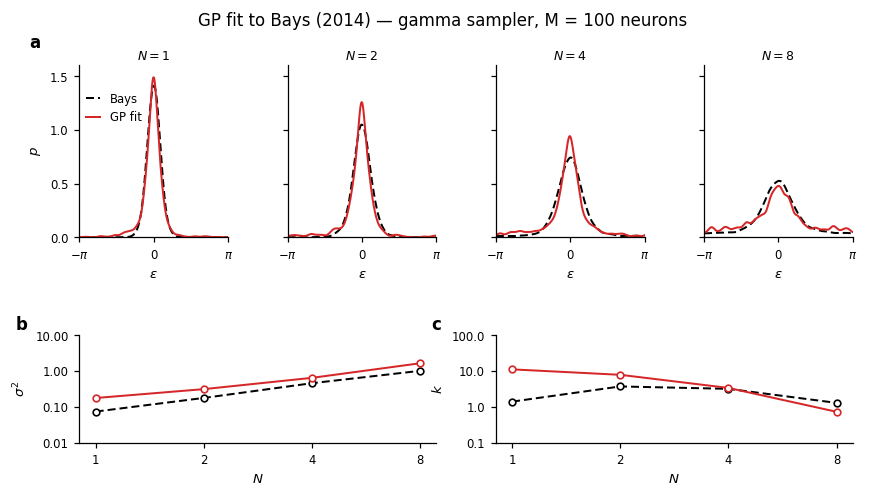

In [14]:
# === Plot: fitted GP (red) vs Bays-generated data (black, dashed) ===
# Fixes vs previous version:
#   * M_FIT now shown in the title.
#   * N-label moved off the curve peak (was colliding in the N=8 panel);
#     wspace tightened so panels sit closer.
#   * Bottom row (b, c) made shorter via height_ratios + wider via wspace,
#     shrinking its aspect ratio.
#   * Variance/kurtosis y-limits are now DATA-DRIVEN (with padding) instead
#     of a hard-coded (0.01, 10) window, so the panel-c lines no longer
#     drop off the bottom of the axis and vanish.

import matplotlib as mpl
from matplotlib.ticker import (
    ScalarFormatter, NullLocator, FixedLocator, MaxNLocator, LogLocator,
)

NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     9,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR       = '#D62728'
BAYS_COLOR     = '#000000'
BAYS_LINESTYLE = (0, (4, 2))   # dashed Bays reference

theta_smooth_fit = np.linspace(-np.pi, np.pi, 500)

KDE_YTICKS = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def _setsize_log_axis(ax, set_sizes):
    """Log x-axis showing only the set sizes actually sampled, no minor ticks."""
    ax.set_xscale('log')
    ax.set_xticks(set_sizes)
    ax.set_xticklabels([str(N) for N in set_sizes])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.get_xaxis().set_major_formatter(ScalarFormatter())


def _pick_kde_yticks(ymax):
    if ymax <= KDE_YTICKS[-1]:
        return [t for t in KDE_YTICKS if t <= ymax]
    locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    ticks = locator.tick_values(0, ymax)
    return [float(t) for t in ticks if 0 <= t <= ymax]


def _data_driven_log_ylim(values, pad_decades=0.25):
    """Symmetric-in-log padding around the actual data range.

    Replaces the old hard-coded (0.01, 10) window that clipped the
    kurtosis lines. Guards against non-positive values before logging.
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        return 0.01, 10.0
    lo_exp = np.floor(np.log10(v.min()) - pad_decades)
    hi_exp = np.ceil(np.log10(v.max()) + pad_decades)
    return 10.0 ** lo_exp, 10.0 ** hi_exp


def _auto_log_y(ax, lo, hi):
    """Decade major ticks across [lo, hi]; labelled, no minor ticks."""
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(NullLocator())
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)


with mpl.rc_context(NATURE_STYLE):
    # ---- Geometry ----
    # Taller figure + height_ratios make row 2 shorter than row 1, which
    # (combined with the 1+1 column span of b and c) shrinks the b/c
    # aspect ratio. wspace tightened so the KDE panels sit closer and the
    # N=8 panel is no longer jammed against the right edge.
    fig = plt.figure(figsize=(7.2, 4.2))
    gs = gridspec.GridSpec(
        2, len(SET_SIZES),
        height_ratios=[1.0, 0.62],
        hspace=0.70, wspace=0.40,
        left=0.08, right=0.975, bottom=0.13, top=0.88,
    )
    fig.suptitle(
        f'GP fit to Bays (2014) — {DISTRIBUTION_FIT} sampler, M = {M_FIT} neurons',
        fontsize=10, y=0.985,
    )

    # ---- precompute KDEs ----
    kdes_data = {N: vonmises_kde(data_errors[N],   theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                 for N in SET_SIZES}
    kdes_fit  = {N: vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                 for N in SET_SIZES}

    peak = max(max(k.max() for k in kdes_data.values()),
               max(k.max() for k in kdes_fit.values()))
    kde_ymax   = peak * 1.08
    kde_yticks = _pick_kde_yticks(kde_ymax)

    # ---- Row 1: KDE overlays ----
    for i, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs[0, i])
        ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                linestyle=BAYS_LINESTYLE,
                label='Bays' if i == 0 else None)
        ax.plot(theta_smooth_fit, kdes_fit[N], color=GP_COLOR, lw=1.2,
                label='GP fit' if i == 0 else None)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        ax.set_yticks(kde_yticks)
        ax.set_ylim(0, kde_ymax)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.set_xlabel(r'$\varepsilon$')
        # Set-size label moved to the upper-LEFT inset so it no longer
        # overlaps the (right-leaning) curve peak in the N=8 panel.
        ax.set_title(f'$N={N}$', fontsize=7.5, pad=3)

        if i == 0:
            ax.set_ylabel(r'$p$')
            ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                      borderaxespad=0.2, bbox_to_anchor=(0.0, 0.88))
            ax.text(-0.34, 1.18, 'a', transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        _style_axes(ax)

    # ---- Row 2: variance and kurtosis vs set size ----
    var_bays  = np.array([circular_moments(data_errors[N])['variance']   for N in SET_SIZES])
    kurt_bays = np.array([circular_moments(data_errors[N])['kurtosis']   for N in SET_SIZES])
    var_fit   = np.array([circular_moments(fitted_errors[N])['variance'] for N in SET_SIZES])
    kurt_fit  = np.array([circular_moments(fitted_errors[N])['kurtosis'] for N in SET_SIZES])

    # gs[1, :2] / gs[1, 2:] splits 4 columns into 2+2.
    ax_var = fig.add_subplot(gs[1, :2])
    ax_var.plot(SET_SIZES, var_bays, marker='o', color=BAYS_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
    ax_var.plot(SET_SIZES, var_fit, marker='o', color=GP_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_var.set_yscale('log')
    _setsize_log_axis(ax_var, SET_SIZES)
    _auto_log_y(ax_var, *_data_driven_log_ylim(np.concatenate([var_bays, var_fit])))
    ax_var.set_xlabel(r'$N$')
    ax_var.set_ylabel(r'$\sigma^2$')
    ax_var.text(-0.18, 1.18, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    ax_kurt = fig.add_subplot(gs[1, 2:])
    ax_kurt.plot(SET_SIZES, kurt_bays, marker='o', color=BAYS_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
    ax_kurt.plot(SET_SIZES, kurt_fit, marker='o', color=GP_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_kurt.set_yscale('log')
    _setsize_log_axis(ax_kurt, SET_SIZES)
    # Data-driven limits keep the kurtosis lines on-canvas instead of
    # dropping below a fixed 0.01 floor.
    _auto_log_y(ax_kurt, *_data_driven_log_ylim(np.concatenate([kurt_bays, kurt_fit])))
    ax_kurt.set_xlabel(r'$N$')
    ax_kurt.set_ylabel(r'$k$')
    ax_kurt.text(-0.18, 1.18, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    fig.savefig(FIT_OUTPUT_DIR / f'gp_fit_{DISTRIBUTION_FIT}_overlay.png',
                dpi=300, bbox_inches='tight')
    fig.savefig(FIT_OUTPUT_DIR / f'gp_fit_{DISTRIBUTION_FIT}_overlay.pdf',
                bbox_inches='tight')
    plt.show()

## Fixed-CV Sweep

At each CV value in `CV_VALUES`, fits only $(\lambda, \gamma)$ with CV held constant inside the forward model. Produces one fit per CV value, so we can see how recovery quality varies with the imposed level of lengthscale heterogeneity.

**Gamma sampler only.** CV is the Gamma sampler's heterogeneity knob; the folded-Normal sampler uses an unbounded $\sigma$ which doesn't translate cleanly. `DISTRIBUTION` for this experiment is therefore fixed at `'gamma'` and only `M` is free to choose.


In [ ]:
# === EXPERIMENT 2 CONTROL — set M for the fixed-CV sweep ===
# Suggested M: 100, 1000, 10000  (must match an existing Bays cache)
# DISTRIBUTION is fixed at 'gamma' for this experiment by design (CV is
# the Gamma sampler's heterogeneity parameter).
M_SWEEP            = 1000
DISTRIBUTION_SWEEP = 'gamma'

# CV values to sweep over. Default: log-spaced from 0.1 to 10 to span the
# range from "near homogeneous" to "heavily heterogeneous lengthscales".
CV_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# Anchored output directory for this experiment only
_now_sweep = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
SWEEP_OUTPUT_DIR = (
    Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
    / f'cv_sweep_M{M_SWEEP}_{_now_sweep}'
)
SWEEP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'=== Fixed-CV Sweep experiment ===')
print(f'  M (GP-side):  {M_SWEEP}')
print(f'  Distribution: {DISTRIBUTION_SWEEP}  (fixed for this experiment)')
print(f'  CV values:    {CV_VALUES}')
print(f'  Output:       {SWEEP_OUTPUT_DIR}')

# Load Bays cache at this experiment's M
sweep_bays_errors, sweep_bays_meta = load_bays_cache(
    M=M_SWEEP, N_trials=10000,
    omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, seed=SEED,
)
print(f'  Bays cache:   {sweep_bays_meta["cache_filename"]}')


=== Fixed-CV Sweep experiment ===
  M (GP-side):  100
  Distribution: gamma  (fixed for this experiment)
  CV values:    [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  Output:       /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/cv_sweep_M100_20260609_144341
  Bays cache:   bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz


In [19]:
# === Fixed-CV sweep: one (lambda, gamma) fit per CV value ===
# Two-parameter fit at each fixed CV. The optimization procedure is the
# same as Experiment 1's main fit; only the forward model has CV pinned.

# Sweep-local bindings — kept distinct from Experiment 1's bindings so
# the two experiments don't trample each other's state.
_M_sweep         = M_SWEEP
N_TRIALS_FIT     = 1000
SEED_FIT         = SEED
N_BINS_FIT       = 50
BIN_EDGES        = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)

# Build fit-target vector from this experiment's Bays cache
sweep_data_hists = {}
for N in SET_SIZES:
    h, _ = np.histogram(sweep_bays_errors[N], bins=BIN_EDGES, density=True)
    sweep_data_hists[N] = h
sweep_data_vector = np.concatenate([sweep_data_hists[N] for N in SET_SIZES])

# Two-parameter fit setup (CV is fixed per run)
X0_FIXED  = [1.0, 2.0]
LO_FIXED  = [0.1, 0.1]
HI_FIXED  = [3.0, 10.0]
DIFF_STEP_FIXED = 0.05

print(f'Fixed-CV sweep: CV ∈ {CV_VALUES}, M = {_M_sweep}')
print(f'  Per-CV fit: x0={X0_FIXED}, bounds=({LO_FIXED}, {HI_FIXED})')
print()

# Forward-model factory: builds a residual function with CV baked in
def make_residual(cv_fixed):
    def gp_forward_fixed(lambda_base, gamma_per_neuron, seed=0):
        max_locs = max(SET_SIZES)
        population = generate_neuron_population(
            n_neurons=_M_sweep, n_orientations=N_THETA, n_locations=max_locs,
            base_lengthscale=lambda_base,
            lengthscale_variability=cv_fixed,
            seed=seed,
            gain_variability=GAIN_VARIABILITY,
            method=DISTRIBUTION_SWEEP,
        )
        thetas = population[0]['orientations']
        f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(_M_sweep)])
                 for loc in range(max_locs)]
        pred_hists = []
        for N in SET_SIZES:
            rng = np.random.RandomState(seed + N)
            errs = run_multiloc_trials(
                f_all, thetas, tuple(range(N)), 0,
                gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
            h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
            pred_hists.append(h)
        return np.concatenate(pred_hists)

    def residual_fn(params):
        lam, gam = params
        return sweep_data_vector - gp_forward_fixed(lam, gam, seed=SEED_FIT)

    return residual_fn, gp_forward_fixed


# Run one fit per CV value
sweep_results = {}
for cv in CV_VALUES:
    print(f'\n--- CV = {cv} ---')
    t0 = time.time()
    residual_fn, forward_fn = make_residual(cv)
    result = least_squares(
        residual_fn, x0=X0_FIXED, bounds=(LO_FIXED, HI_FIXED),
        method='trf', diff_step=DIFF_STEP_FIXED, verbose=0,
    )
    lam_hat, gam_hat = result.x
    print(f'  lambda_hat = {lam_hat:.4f},  gamma_hat = {gam_hat:.4f},  '
          f'cost = {result.cost:.4f},  time = {time.time()-t0:.1f}s')

    # Final predictions at the fitted (lambda, gamma) with this CV
    max_locs = max(SET_SIZES)
    population_fit = generate_neuron_population(
        n_neurons=_M_sweep, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lam_hat,
        lengthscale_variability=cv,
        seed=SEED_FIT,
        gain_variability=GAIN_VARIABILITY,
        method=DISTRIBUTION_SWEEP,
    )
    thetas_fit = population_fit[0]['orientations']
    f_all_fit  = [np.array([population_fit[n]['f_samples'][loc, :] for n in range(_M_sweep)])
                  for loc in range(max_locs)]
    fitted_errors_per_cv = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED_FIT + 7000 + N)
        errs = run_multiloc_trials(
            f_all_fit, thetas_fit, tuple(range(N)), 0,
            gam_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        fitted_errors_per_cv[N] = errs
    sweep_results[cv] = {
        'lambda_hat':    lam_hat,
        'gamma_hat':     gam_hat,
        'omega_hat':     lam_hat ** 2,
        'gamma_total':   gam_hat * _M_sweep,
        'cost':          result.cost,
        'fitted_errors': fitted_errors_per_cv,
    }

print('\n=== Sweep summary ===')
print(f'{"CV":>6}  {"λ̂":>8}  {"γ̂":>8}  {"ω̂":>8}  {"γ_total":>10}  {"cost":>8}')
for cv in CV_VALUES:
    r = sweep_results[cv]
    print(f'{cv:>6.2f}  {r["lambda_hat"]:>8.4f}  {r["gamma_hat"]:>8.4f}  '
          f'{r["omega_hat"]:>8.4f}  {r["gamma_total"]:>10.2f}  {r["cost"]:>8.4f}')

# Make the cached Bays errors visible under the name the downstream
# diagnostic/summary cells expect.
bays_cached_errors = sweep_bays_errors


Fixed-CV sweep: CV ∈ [0.1, 0.5, 1.0, 2.0, 5.0, 10.0], M = 100
  Per-CV fit: x0=[1.0, 2.0], bounds=([0.1, 0.1], [3.0, 10.0])


--- CV = 0.1 ---
  lambda_hat = 1.0344,  gamma_hat = 2.0064,  cost = 0.1698,  time = 47.5s

--- CV = 0.5 ---
  lambda_hat = 1.0526,  gamma_hat = 1.9704,  cost = 0.4006,  time = 33.1s

--- CV = 1.0 ---
  lambda_hat = 1.1011,  gamma_hat = 1.8990,  cost = 3.6311,  time = 30.8s

--- CV = 2.0 ---
  lambda_hat = 1.6785,  gamma_hat = 1.1512,  cost = 5.2345,  time = 39.2s

--- CV = 5.0 ---
  lambda_hat = 1.1984,  gamma_hat = 0.8609,  cost = 7.1334,  time = 33.7s

--- CV = 10.0 ---
  lambda_hat = 0.9382,  gamma_hat = 1.8944,  cost = 13.1832,  time = 11.8s

=== Sweep summary ===
    CV        λ̂        γ̂        ω̂     γ_total      cost
  0.10    1.0344    2.0064    1.0700      200.64    0.1698
  0.50    1.0526    1.9704    1.1080      197.04    0.4006
  1.00    1.1011    1.8990    1.2125      189.90    3.6311
  2.00    1.6785    1.1512    2.8172      115.12    5.2345
  5

In [27]:
# Metadata helpers (were missing from the Cell 1 that actually ran)
M_SIZE   = M_FIT if 'M_FIT' in globals() else (M_DATA if 'M_DATA' in globals() else None)
DIST_TAG = DISTRIBUTION_FIT if 'DISTRIBUTION_FIT' in globals() else 'unknown'

def _meta_suffix():
    """Filename fragment, e.g. 'M100_gamma'."""
    m = f'M{M_SIZE}' if M_SIZE is not None else 'MNA'
    return f'{m}_{DIST_TAG}'

def _meta_title():
    """Title fragment, e.g. 'M = 100 neurons, gamma sampler'."""
    m = f'M = {M_SIZE} neurons' if M_SIZE is not None else 'M = ?'
    return f'{m}, {DIST_TAG} sampler'

print(f'Metadata: {_meta_title()}  (suffix: {_meta_suffix()})')

Metadata: M = 100 neurons, gamma sampler  (suffix: M100_gamma)


In [28]:
# === Part 1 — Diagnostic: are variance/kurtosis values correct and consistent? ===
DISAGREE_REL_TOL = 0.10   # 10% relative difference flags a warning

print('=== Diagnostic: variance/kurtosis consistency ===')
print('  cm  = circular_moments() output    [what panel b plots]')
print('  raw = independent reimplementation [should match cm exactly]')
print('  kde = computed from KDE histogram  [reveals if KDE hides tails]')
print()
print(f'{"CV":>6} {"N":>3}  '
      f'{"σ²_Bays (cm)":>13} {"σ²_GP (cm)":>13} {"σ²_GP (raw)":>13} {"σ²_GP (kde)":>13}  '
      f'{"k_Bays":>9} {"k_GP":>9}  flag')
print('-' * 110)

any_flags = False
for cv in CV_VALUES:
    fitted_errors_cv = sweep_results[cv]['fitted_errors']
    for N in SET_SIZES:
        v_b_cm = circular_moments(bays_errs[N])['variance']
        k_b_cm = circular_moments(bays_errs[N])['kurtosis']

        e = fitted_errors_cv[N]
        v_g_cm  = circular_moments(e)['variance']
        v_g_raw = _direct_circular_variance(e)
        k_g_cm  = circular_moments(e)['kurtosis']

        density = vonmises_kde(e, theta_smooth_fit, kappa=KAPPA_BAYS_AC)
        v_g_kde = _kde_circular_variance(theta_smooth_fit, density)

        flag = ''
        if abs(v_g_cm - v_g_raw) / max(abs(v_g_cm), 1e-12) > 1e-6:
            flag += '!cm/raw '
            any_flags = True
        if abs(v_g_cm - v_g_kde) / max(abs(v_g_cm), 1e-12) > DISAGREE_REL_TOL:
            flag += '!cm/kde '

        print(f'{cv:>6.2f} {N:>3}  '
              f'{v_b_cm:>13.4f} {v_g_cm:>13.4f} {v_g_raw:>13.4f} {v_g_kde:>13.4f}  '
              f'{k_b_cm:>9.3f} {k_g_cm:>9.3f}  {flag}')

print()
if any_flags:
    print('!cm/raw flags indicate a real numerical inconsistency between')
    print('  circular_moments() and the independent reimplementation. Investigate.')
print('!cm/kde flags indicate KDE smoothing diverges from the variance statistic')
print('  by >10%. Expected at high CV where long tails are present.')
print()

=== Diagnostic: variance/kurtosis consistency ===
  cm  = circular_moments() output    [what panel b plots]
  raw = independent reimplementation [should match cm exactly]
  kde = computed from KDE histogram  [reveals if KDE hides tails]

    CV   N   σ²_Bays (cm)    σ²_GP (cm)   σ²_GP (raw)   σ²_GP (kde)     k_Bays      k_GP  flag
--------------------------------------------------------------------------------------------------------------
  0.10   1         0.0734        0.1491        0.1491        0.1620      1.394    12.495  
  0.10   2         0.1770        0.2846        0.2846        0.2976      3.709     7.183  
  0.10   4         0.4577        0.5011        0.5011        0.5147      3.178     3.975  
  0.10   8         1.0153        1.0383        1.0383        1.0539      1.286     1.536  
  0.50   1         0.0734        0.1942        0.1942        0.2074      1.394    12.962  
  0.50   2         0.1770        0.3564        0.3564        0.3709      3.709     9.080  
  0.50   4

In [29]:
# === Part 2 — Bays reference arrays + shared, sweep-wide log y-ranges ===
var_bays_arr  = np.array([circular_moments(bays_errs[N])['variance'] for N in SET_SIZES])
kurt_bays_arr = np.array([circular_moments(bays_errs[N])['kurtosis'] for N in SET_SIZES])

var_gp_all, kurt_gp_all = [], []
for cv in CV_VALUES:
    for N in SET_SIZES:
        m = circular_moments(sweep_results[cv]['fitted_errors'][N])
        var_gp_all.append(m['variance'])
        kurt_gp_all.append(m['kurtosis'])
var_gp_all  = np.array(var_gp_all)
kurt_gp_all = np.array(kurt_gp_all)

print('Data ranges across the sweep:')
print(f'  variance:  Bays in [{var_bays_arr.min():.4f}, {var_bays_arr.max():.4f}], '
      f'GP in [{var_gp_all.min():.4f}, {var_gp_all.max():.4f}]')
print(f'  kurtosis:  Bays in [{kurt_bays_arr.min():.4f}, {kurt_bays_arr.max():.4f}], '
      f'GP in [{kurt_gp_all.min():.4f}, {kurt_gp_all.max():.4f}]')
print()


def _data_driven_log_ylim(values, pad_decades=0.25):
    """Decade-padded [lo, hi] bracketing the positive, finite data.

    Computed ONCE over the whole sweep so every figure shares the same
    non-clipping range. Non-positive values can't appear on a log axis;
    if any are present we report a count so they aren't silently dropped.
    """
    v = np.asarray(values, dtype=float)
    finite = v[np.isfinite(v)]
    n_neg = int(np.sum(finite <= 0))
    pos = finite[finite > 0]
    if pos.size == 0:
        return 0.01, 10.0, n_neg
    lo_exp = np.floor(np.log10(pos.min()) - pad_decades)
    hi_exp = np.ceil(np.log10(pos.max()) + pad_decades)
    return 10.0 ** lo_exp, 10.0 ** hi_exp, n_neg


VAR_LO, VAR_HI, _var_neg = _data_driven_log_ylim(
    np.concatenate([var_bays_arr, var_gp_all]))
KURT_LO, KURT_HI, _kurt_neg = _data_driven_log_ylim(
    np.concatenate([kurt_bays_arr, kurt_gp_all]))

print(f'Shared variance y-range:  [{VAR_LO:g}, {VAR_HI:g}]')
print(f'Shared kurtosis y-range:  [{KURT_LO:g}, {KURT_HI:g}]')
if _kurt_neg:
    print(f'  WARNING: {_kurt_neg} kurtosis value(s) <= 0 cannot be shown on a '
          f'log axis. Consider a symlog scale if these matter.')
if _var_neg:
    print(f'  WARNING: {_var_neg} variance value(s) <= 0 (unexpected).')
print()

Data ranges across the sweep:
  variance:  Bays in [0.0734, 1.0153], GP in [0.1491, 3.2081]
  kurtosis:  Bays in [1.2862, 3.7087], GP in [0.3393, 16.5259]

Shared variance y-range:  [0.01, 10]
Shared kurtosis y-range:  [0.1, 100]



Plotting per-CV figure for CV = 0.1


<Figure size 864x552 with 0 Axes>

<Figure size 864x336 with 0 Axes>

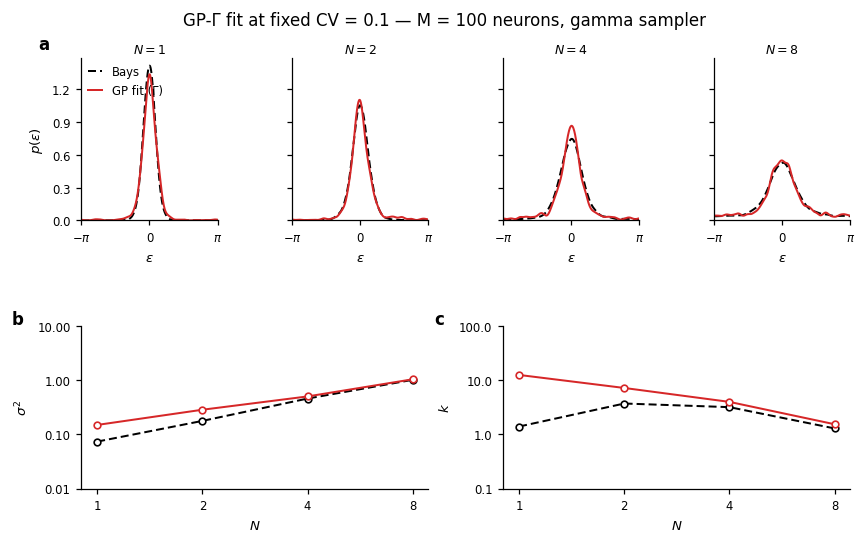

Plotting per-CV figure for CV = 0.5


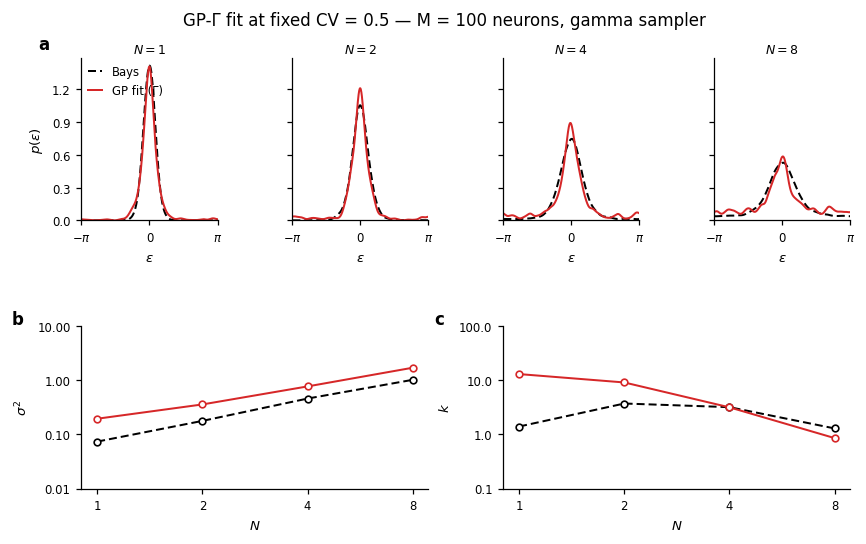

Plotting per-CV figure for CV = 1.0


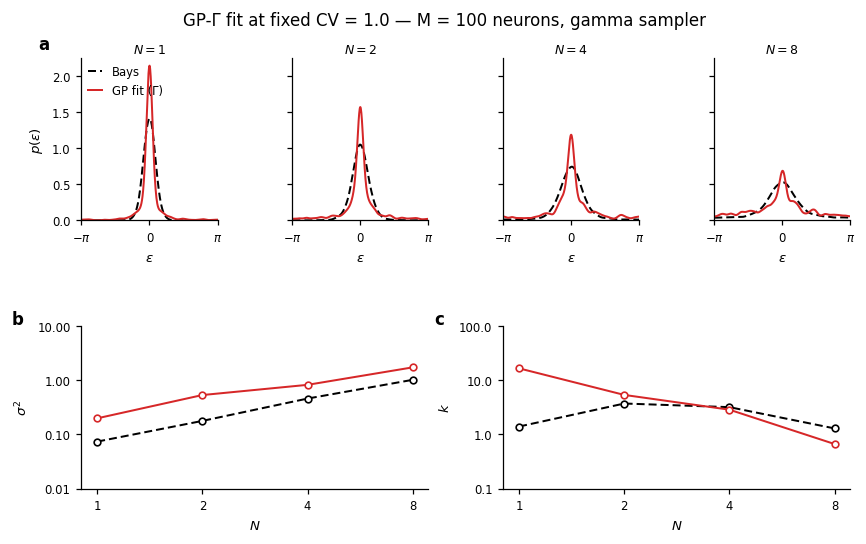

Plotting per-CV figure for CV = 2.0


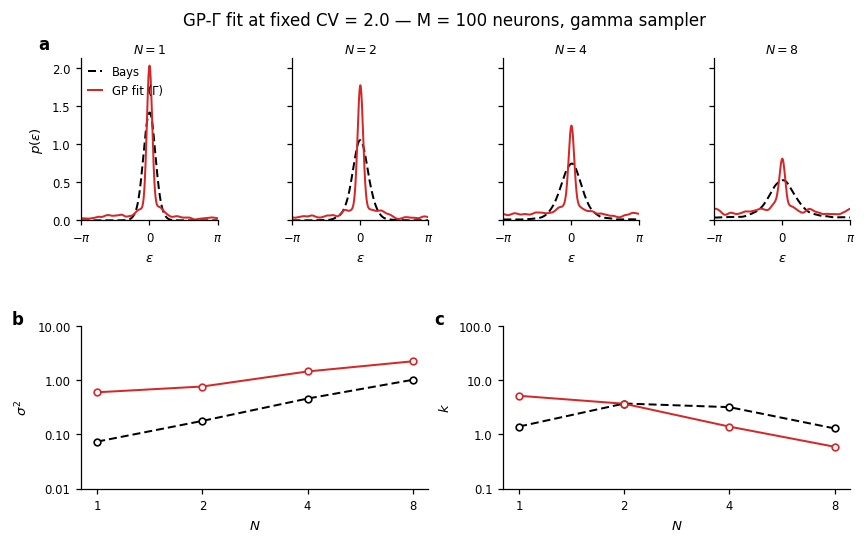

Plotting per-CV figure for CV = 5.0


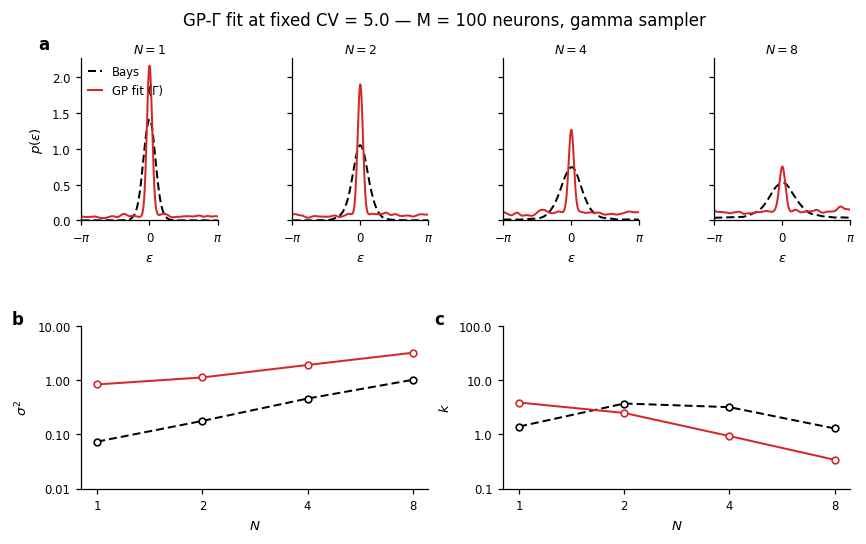

Plotting per-CV figure for CV = 10.0


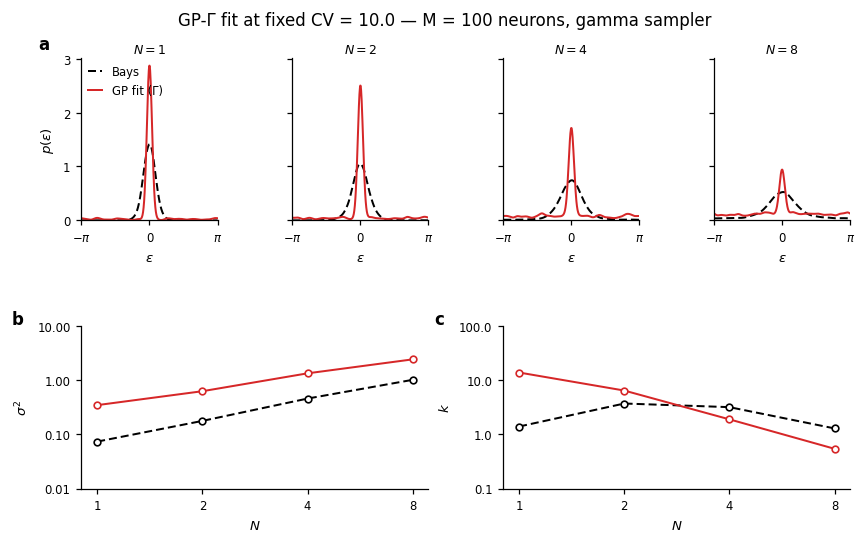

In [30]:
# === Part 3 — Style, helpers, and per-CV detail figures ===
NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     9,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR       = '#D62728'
BAYS_COLOR     = '#000000'
BAYS_LINESTYLE = (0, (4, 2))   # dashed Bays reference
KDE_YTICKS     = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def _setsize_log_axis(ax, set_sizes):
    """Log x-axis showing only the set sizes actually sampled, no minor ticks."""
    ax.set_xscale('log')
    ax.set_xticks(set_sizes)
    ax.set_xticklabels([str(N) for N in set_sizes])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.get_xaxis().set_major_formatter(ScalarFormatter())


def _auto_log_y(ax, lo, hi):
    """Decade major ticks across [lo, hi] from the sweep-wide data extent."""
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(NullLocator())
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)


def _pick_kde_yticks(ymax):
    if ymax <= KDE_YTICKS[-1]:
        return [t for t in KDE_YTICKS if t <= ymax]
    locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    ticks = locator.tick_values(0, ymax)
    return [float(t) for t in ticks if 0 <= t <= ymax]


def plot_cv_fit(cv, result):
    fitted_errors = result['fitted_errors']

    with mpl.rc_context(NATURE_STYLE):
        fig = plt.figure(figsize=(7.2, 4.6))
        gs = gridspec.GridSpec(
            2, len(SET_SIZES),
            hspace=0.65, wspace=0.55,
            left=0.08, right=0.97, bottom=0.12, top=0.90,
        )

        fig.suptitle(f'GP-\u0393 fit at fixed CV = {cv} — {_meta_title()}',
                     fontsize=10, y=0.985)

        kdes_data = {N: vonmises_kde(bays_errs[N],     theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                     for N in SET_SIZES}
        kdes_fit  = {N: vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                     for N in SET_SIZES}

        peak = max(max(k.max() for k in kdes_data.values()),
                   max(k.max() for k in kdes_fit.values()))
        kde_ymax = peak * 1.05
        kde_yticks = _pick_kde_yticks(kde_ymax)

        # ---- Row 1: KDE overlays ----
        for i, N in enumerate(SET_SIZES):
            ax = fig.add_subplot(gs[0, i])
            ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                    linestyle=BAYS_LINESTYLE, label='Bays' if i == 0 else None)
            ax.plot(theta_smooth_fit, kdes_fit[N], color=GP_COLOR, lw=1.2,
                    label='GP fit (\u0393)' if i == 0 else None)
            ax.set_xlim(-np.pi, np.pi)
            ax.set_xticks([-np.pi, 0, np.pi])
            ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
            ax.set_yticks(kde_yticks)
            ax.set_ylim(0, kde_ymax)
            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())
            ax.set_xlabel(r'$\varepsilon$')
            ax.set_title(f'$N={N}$', fontsize=7.5, pad=3)

            if i == 0:
                ax.set_ylabel(r'$p(\varepsilon)$')
                ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                          borderaxespad=0.2)
                ax.text(-0.32, 1.14, 'a', transform=ax.transAxes,
                        fontsize=10, fontweight='bold', va='top')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            _style_axes(ax)

        # ---- Row 2: variance and kurtosis (shared sweep-wide log range) ----
        var_fit  = np.array([circular_moments(fitted_errors[N])['variance']  for N in SET_SIZES])
        kurt_fit = np.array([circular_moments(fitted_errors[N])['kurtosis']  for N in SET_SIZES])

        ax_var = fig.add_subplot(gs[1, :2])
        ax_var.plot(SET_SIZES, var_bays_arr, marker='o', color=BAYS_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
        ax_var.plot(SET_SIZES, var_fit, marker='o', color=GP_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0)
        ax_var.set_yscale('log')
        _setsize_log_axis(ax_var, SET_SIZES)
        _auto_log_y(ax_var, VAR_LO, VAR_HI)
        ax_var.set_xlabel(r'$N$')
        ax_var.set_ylabel(r'$\sigma^2$')
        ax_var.text(-0.20, 1.10, 'b', transform=ax_var.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_var)

        ax_kurt = fig.add_subplot(gs[1, 2:])
        ax_kurt.plot(SET_SIZES, kurt_bays_arr, marker='o', color=BAYS_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
        ax_kurt.plot(SET_SIZES, kurt_fit, marker='o', color=GP_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0)
        ax_kurt.set_yscale('log')
        _setsize_log_axis(ax_kurt, SET_SIZES)
        _auto_log_y(ax_kurt, KURT_LO, KURT_HI)
        ax_kurt.set_xlabel(r'$N$')
        ax_kurt.set_ylabel(r'$k$')
        ax_kurt.text(-0.20, 1.10, 'c', transform=ax_kurt.transAxes,
                     fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_kurt)

        cv_tag = str(cv).replace('.', 'p')
        stem = f'cv_sweep_{_meta_suffix()}_cv{cv_tag}'
        png_path = os.path.join(RUN_DIR, f'{stem}.png')
        pdf_path = os.path.join(RUN_DIR, f'{stem}.pdf')
        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
        plt.show()


for cv in CV_VALUES:
    print(f'Plotting per-CV figure for CV = {cv}')
    plot_cv_fit(cv, sweep_results[cv])

In [26]:
for name in ['_meta_title', '_meta_suffix', 'theta_smooth_fit',
             'VAR_LO', 'KURT_LO', 'NATURE_STYLE', 'sweep_results', 'CV_VALUES']:
    print(f'{name:20s} {"OK" if name in globals() else "MISSING"}')

_meta_title          MISSING
_meta_suffix         MISSING
theta_smooth_fit     OK
VAR_LO               OK
KURT_LO              OK
NATURE_STYLE         OK
sweep_results        OK
CV_VALUES            OK


In [25]:
# === Part 4 — Summary figure: variance & kurtosis vs N, all CVs overlaid ===
norm = Normalize(vmin=0, vmax=len(CV_VALUES) - 1)
cmap = plt.get_cmap('YlOrRd')
cv_colors = [cmap(0.35 + 0.6 * norm(i)) for i in range(len(CV_VALUES))]

with mpl.rc_context(NATURE_STYLE):
    fig = plt.figure(figsize=(7.2, 2.8))
    gs = gridspec.GridSpec(
        1, 2,
        wspace=0.55,
        left=0.08, right=0.97, bottom=0.24, top=0.78,
    )

    fig.suptitle(
        f'CV sweep — variance and kurtosis vs set size, all CVs overlaid\n'
        f'({_meta_title()})',
        fontsize=9, y=0.99,
    )

    # --- Variance panel: holds the single legend ---
    ax_var = fig.add_subplot(gs[0, 0])
    ax_var.plot(SET_SIZES, var_bays_arr, marker='o',
                color=BAYS_COLOR, lw=1.5, ms=5, mfc='white', mew=1.2,
                linestyle=BAYS_LINESTYLE, label='Bays', zorder=10)
    for i, cv in enumerate(CV_VALUES):
        v = np.array([circular_moments(sweep_results[cv]['fitted_errors'][N])['variance']
                      for N in SET_SIZES])
        ax_var.plot(SET_SIZES, v, marker='o',
                    color=cv_colors[i], lw=1.2, ms=4, mfc='white', mew=1.0,
                    label=f'CV = {cv}')
    ax_var.set_yscale('log')
    _setsize_log_axis(ax_var, SET_SIZES)
    _auto_log_y(ax_var, VAR_LO, VAR_HI)
    ax_var.set_xlabel(r'$N$')
    ax_var.set_ylabel(r'$\sigma^2$')
    ax_var.legend(loc='upper left', frameon=False, handlelength=1.5,
                  fontsize=6.5, ncol=1)
    ax_var.text(-0.20, 1.12, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    # --- Kurtosis panel: no legend (shared with variance panel) ---
    ax_kurt = fig.add_subplot(gs[0, 1])
    ax_kurt.plot(SET_SIZES, kurt_bays_arr, marker='o',
                 color=BAYS_COLOR, lw=1.5, ms=5, mfc='white', mew=1.2,
                 linestyle=BAYS_LINESTYLE, zorder=10)
    for i, cv in enumerate(CV_VALUES):
        k = np.array([circular_moments(sweep_results[cv]['fitted_errors'][N])['kurtosis']
                      for N in SET_SIZES])
        ax_kurt.plot(SET_SIZES, k, marker='o',
                     color=cv_colors[i], lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_kurt.set_yscale('log')
    _setsize_log_axis(ax_kurt, SET_SIZES)
    _auto_log_y(ax_kurt, KURT_LO, KURT_HI)
    ax_kurt.set_xlabel(r'$N$')
    ax_kurt.set_ylabel(r'$k$')
    ax_kurt.text(-0.20, 1.12, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    summary_stem = f'cv_sweep_{_meta_suffix()}_variance_kurtosis'
    summary_png = os.path.join(RUN_DIR, f'{summary_stem}.png')
    summary_pdf = os.path.join(RUN_DIR, f'{summary_stem}.pdf')
    fig.savefig(summary_png, dpi=300, bbox_inches='tight')
    fig.savefig(summary_pdf, bbox_inches='tight')
    plt.show()

print(f'\nAll figures saved to: {RUN_DIR}')

NameError: name '_meta_title' is not defined

## Other Experiments (use global `M` and `GP_SAMPLER`)

These sections are kept for context but are no longer the primary focus of the notebook. They use the **global** `M` and `GP_SAMPLER` from the Setup configuration, so changing those flags affects every cell from this point onward.

If you want to switch sampler or M just for one of these sections, the easiest path is to change the global flags, re-run from the top of this section, and let the figures land in their respective `OUTPUT_DIR` subdirectories.


### GP Sweep — Group Mean


In [17]:
# === Per-section overrides (None = use global) ===
M_LOC                       = None     # e.g. 100, 1000, 10000
GP_SAMPLER_LOC              = None     # e.g. 'folded_normal' or 'gamma'
LENGTHSCALE_VARIABILITY     = 0.3      # GP-side spread of lengthscales
GAIN_VARIABILITY            = 0.0      # GP-side amplitude variability
N_TRIALS                    = 5000     # trials per set size, per seed

_M_local       = M if M_LOC is None else M_LOC
_sampler_local = GP_SAMPLER if GP_SAMPLER_LOC is None else GP_SAMPLER_LOC
_gamma_local   = GAMMA_TOTAL_BAYS / _M_local

print(f'GP group sweep: M={_M_local}, sampler={_sampler_local!r}, '
      f'lengthscale_var={LENGTHSCALE_VARIABILITY}, '
      f'gain_var={GAIN_VARIABILITY}, trials={N_TRIALS}, seeds={N_SEEDS}')

max_locs = max(SET_SIZES)
t0 = time.time()
all_seeds = []

for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(
        _M_local, N_THETA, LAMBDA_BASE, max_locs, cseed,
        lengthscale_variability=LENGTHSCALE_VARIABILITY,
        gain_variability=GAIN_VARIABILITY,
        sampler=_sampler_local,
    )
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            _gamma_local, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors':    errors,
            'variance':  moments['variance'],
            'kurtosis':  moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
        print(f'  seed={s} N={N}: var={moments["variance"]:.4f} '
              f'kurt={moments["kurtosis"]:.3f}')
    all_seeds.append(seed_data)

# Aggregate across seeds
summary = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds]
    ks = [sd[N]['kurtosis'] for sd in all_seeds]
    emps = np.array([sd[N]['deviation']['empirical'] for sd in all_seeds])
    devs = np.array([sd[N]['deviation']['deviation'] for sd in all_seeds])
    summary[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'emp_mean':  np.mean(emps, axis=0),
        'emp_se':    np.std(emps, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(emps[0]),
        'dev_mean':  np.mean(devs, axis=0),
        'dev_se':    np.std(devs, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(devs[0]),
    }
bins = all_seeds[0][SET_SIZES[0]]['deviation']['bin_centers']
print(f'Done in {time.time()-t0:.1f}s')


GP group sweep: M=100, sampler='folded_normal', lengthscale_var=0.3, gain_var=0.0, trials=5000, seeds=5
  seed=0 N=1: var=0.2609 kurt=12.051
  seed=0 N=2: var=0.3972 kurt=7.484
  seed=0 N=4: var=0.5208 kurt=5.583
  seed=0 N=8: var=1.2316 kurt=1.360
  seed=1 N=1: var=0.2761 kurt=10.106
  seed=1 N=2: var=0.3802 kurt=7.562
  seed=1 N=4: var=0.5984 kurt=4.282
  seed=1 N=8: var=1.4609 kurt=1.176
  seed=2 N=1: var=0.2779 kurt=8.752
  seed=2 N=2: var=0.5539 kurt=4.004
  seed=2 N=4: var=0.8497 kurt=2.167
  seed=2 N=8: var=1.3113 kurt=1.232
  seed=3 N=1: var=0.2718 kurt=9.520
  seed=3 N=2: var=0.3441 kurt=7.571
  seed=3 N=4: var=0.6856 kurt=3.247
  seed=3 N=8: var=1.1274 kurt=1.481
  seed=4 N=1: var=0.1911 kurt=15.836
  seed=4 N=2: var=0.2412 kurt=13.153
  seed=4 N=4: var=0.7228 kurt=3.415
  seed=4 N=8: var=1.3792 kurt=1.209
Done in 9.0s


### GP Sweep — Single Subject


In [18]:
# === Per-section overrides ===
M_LOC                       = None
GP_SAMPLER_LOC              = None
OMEGA_SINGLE                = 0.65
GAMMA_SINGLE_TOTAL          = 113.0

_M_local       = M if M_LOC is None else M_LOC
_sampler_local = GP_SAMPLER if GP_SAMPLER_LOC is None else GP_SAMPLER_LOC

LAMBDA_BASE_SINGLE = np.sqrt(OMEGA_SINGLE)
GAMMA_SINGLE       = GAMMA_SINGLE_TOTAL / _M_local

print(f'GP single-subject sweep: omega={OMEGA_SINGLE}, '
      f'gamma_total={GAMMA_SINGLE_TOTAL} Hz, M={_M_local}, sampler={_sampler_local!r}')

max_locs = max(SET_SIZES)
t0 = time.time()
all_seeds_single = []
for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(
        _M_local, N_THETA, LAMBDA_BASE_SINGLE, max_locs, cseed,
        lengthscale_variability=LENGTHSCALE_VARIABILITY,
        gain_variability=GAIN_VARIABILITY,
        sampler=_sampler_local,
    )
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            GAMMA_SINGLE, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors':    errors,
            'variance':  moments['variance'],
            'kurtosis':  moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
    all_seeds_single.append(seed_data)

summary_single = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds_single]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_single]
    summary_single[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
    }
print(f'Done in {time.time()-t0:.1f}s')


GP single-subject sweep: omega=0.65, gamma_total=113.0 Hz, M=100, sampler='folded_normal'
Done in 11.4s


### Bays Summary (from Cache)


In [19]:
# === Reconstruct seed-stratified summary from the Bays cache ===
# The cache stores 10,000 trials per set size as a single array. To
# mimic the multi-seed sweep structure that the overlay plot expects,
# we partition the cached errors into N_SEEDS equal chunks. The
# resulting summary_bays values match the cached statistics in
# expectation but have honest seed-level standard errors.

all_seeds_bays = []
_n_trials_per_seed = len(bays_cached_errors[SET_SIZES[0]]) // N_SEEDS
print(f'Partitioning Bays cache into {N_SEEDS} pseudo-seeds of '
      f'{_n_trials_per_seed} trials each')

for s in range(N_SEEDS):
    seed_data = {}
    lo, hi = s * _n_trials_per_seed, (s + 1) * _n_trials_per_seed
    for N in SET_SIZES:
        errors = bays_cached_errors[N][lo:hi]
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors':    errors,
            'variance':  moments['variance'],
            'kurtosis':  moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
    all_seeds_bays.append(seed_data)

summary_bays = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds_bays]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_bays]
    emps = np.array([sd[N]['deviation']['empirical']  for sd in all_seeds_bays])
    devs = np.array([sd[N]['deviation']['deviation']  for sd in all_seeds_bays])
    n_eff = N_SEEDS
    summary_bays[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'emp_mean':  np.mean(emps, axis=0),
        'emp_se':    (np.std(emps, axis=0, ddof=1) / np.sqrt(n_eff)
                      if n_eff > 1 else np.zeros_like(emps[0])),
        'dev_mean':  np.mean(devs, axis=0),
        'dev_se':    (np.std(devs, axis=0, ddof=1) / np.sqrt(n_eff)
                      if n_eff > 1 else np.zeros_like(devs[0])),
    }
bins_bays = all_seeds_bays[0][SET_SIZES[0]]['deviation']['bin_centers']

# Also build a single-subject Bays summary by re-using the cache —
# we don't have a separate "single-subject" cache, so we use the same
# group-mean cache here. If you need a true single-subject cache at
# omega=0.65, build a separate cache file and load it explicitly.
all_seeds_bays_single = all_seeds_bays   # alias — same parameters
summary_bays_single = summary_bays

print('Built summary_bays and summary_bays_single from cache')


Partitioning Bays cache into 5 pseudo-seeds of 2000 trials each
Built summary_bays and summary_bays_single from cache


### Figure 2 — GP Variant (panels a–f)


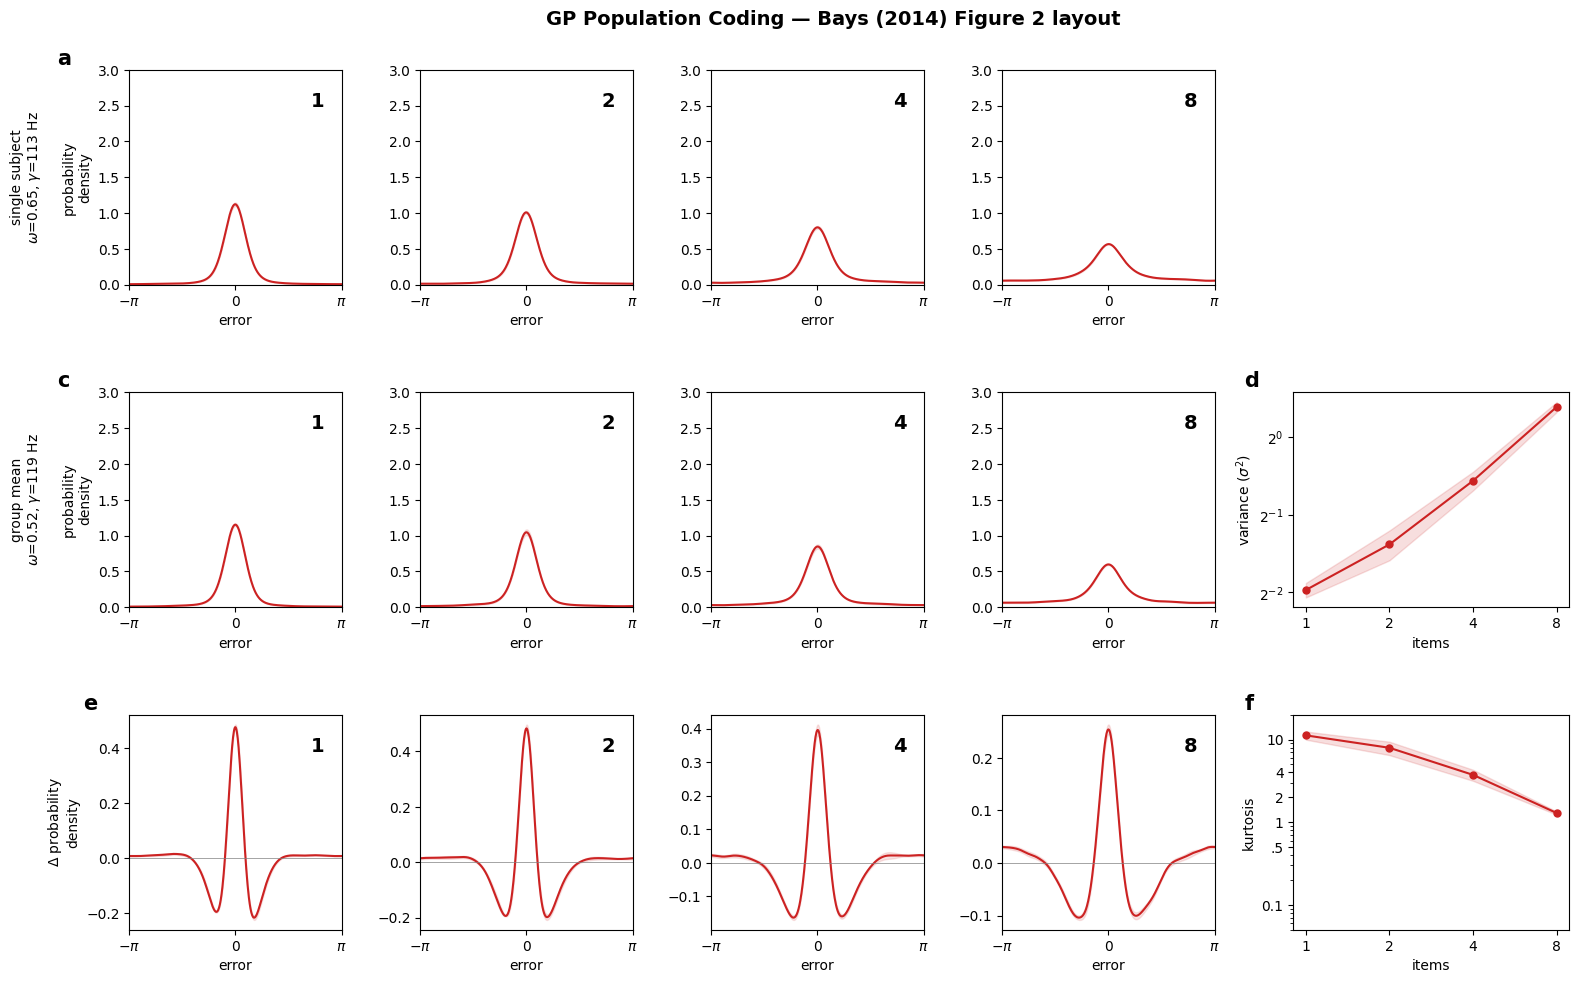

In [20]:
# === GP figure: two-row layout matching Bays (2014) Figure 2 ===
# Row 1: single-subject params (omega=0.65, gamma=113 Hz) — distributions only
# Row 2: group-mean params     (omega=0.52, gamma=119 Hz) — distributions + d/e/f

RED = '#CC2222'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(
    3, len(SET_SIZES) + 1,
    width_ratios=[1] * len(SET_SIZES) + [1.3],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.96, bottom=0.06, top=0.92,
)

# ---- Row 1: SINGLE-SUBJECT distributions (panel a equivalent) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[0, i])
    seed_kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        for sd in all_seeds_single
    ])
    kde_mean = seed_kdes.mean(axis=0)
    kde_se = (seed_kdes.std(axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'single subject\n$\\omega$={OMEGA_SINGLE}, '
                      f'$\\gamma$={GAMMA_SINGLE_TOTAL:.0f} Hz\n\nprobability\ndensity')
        ax.text(-0.34, 1.10, r'$\mathbf{a}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Row 1, last column: leave blank (panel b in paper is parameter scatter, not a curve)
ax_blank = fig.add_subplot(gs[0, len(SET_SIZES)])
ax_blank.axis('off')

# ---- Row 2: GROUP-MEAN distributions (panel c equivalent) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    seed_kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        for sd in all_seeds
    ])
    kde_mean = seed_kdes.mean(axis=0)
    kde_se = (seed_kdes.std(axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'group mean\n$\\omega$={OMEGA_BAYS}, '
                      f'$\\gamma$={GAMMA_TOTAL_BAYS:.0f} Hz\n\nprobability\ndensity')
        ax.text(-0.34, 1.10, r'$\mathbf{c}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Row 2, last column: panel d (variance vs items at group-mean params)
ax_d = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
vm  = np.array([summary[N]['var_mean'] for N in SET_SIZES])
vse = np.array([summary[N]['var_se']   for N in SET_SIZES])
ax_d.plot(ns, vm, 'o-', color=RED, lw=1.5, ms=5)
ax_d.fill_between(ns, vm - vse, vm + vse, color=RED, alpha=0.15)
ax_d.set_xscale('log', base=2); ax_d.set_yscale('log', base=2)
ax_d.set_xticks(SET_SIZES); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items'); ax_d.set_ylabel(r'variance ($\sigma^2$)')
ax_d.text(-0.18, 1.10, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---- Row 3: deviation from normal (e) + kurtosis (f), group-mean only ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    all_err = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_e = np.abs(np.mean(np.exp(1j * all_err)))
    kappa_e = _estimate_von_mises_kappa(max(rho1_e, 1e-6))
    vm_ref = vonmises.pdf(theta_smooth, kappa_e)
    emp_kde = vonmises_kde(all_err, theta_smooth, kappa=KAPPA_PANEL_E)
    dev_smooth = emp_kde - vm_ref
    ax.plot(theta_smooth, dev_smooth, color=RED, lw=1.5)
    seed_devs = []
    for sd in all_seeds:
        e_s = sd[N]['errors']
        rho1_s = np.abs(np.mean(np.exp(1j * e_s)))
        kappa_s = _estimate_von_mises_kappa(max(rho1_s, 1e-6))
        vm_s = vonmises.pdf(theta_smooth, kappa_s)
        emp_s = vonmises_kde(e_s, theta_smooth, kappa=KAPPA_PANEL_E)
        seed_devs.append(emp_s - vm_s)
    seed_devs = np.array(seed_devs)
    if N_SEEDS > 1:
        dev_se = np.std(seed_devs, axis=0, ddof=1) / np.sqrt(N_SEEDS)
    else:
        dev_se = np.zeros_like(dev_smooth)
    ax.fill_between(theta_smooth, dev_smooth - dev_se, dev_smooth + dev_se,
                    color=RED, alpha=0.12)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability' + '\ndensity')
        ax.text(-0.22, 1.10, r'$\mathbf{e}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
km  = np.array([summary[N]['kurt_mean'] for N in SET_SIZES])
kse = np.array([summary[N]['kurt_se']   for N in SET_SIZES])
ax_f.plot(ns, km, 'o-', color=RED, lw=1.5, ms=5)
ax_f.fill_between(ns, km - kse, km + kse, color=RED, alpha=0.15)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')
ax_f.text(-0.18, 1.10, r'$\mathbf{f}$', transform=ax_f.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding — Bays (2014) Figure 2 layout',
             fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / 'bays_fig2_gp.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'bays_fig2_gp.pdf', bbox_inches='tight')
plt.show()


### GP vs Bays — Direct Overlay


In [21]:
# === Overlay: GP variant (red) vs Bays parametric (black) ===
# Row 1: single-subject params (omega=0.65, gamma=113 Hz) — distributions only
# Row 2: group-mean params     (omega=0.52, gamma=119 Hz) — distributions + d/e/f
# Row 3: deviation (e) + kurtosis (f), at group-mean
#
# Within each row, BOTH curves use identical (omega, gamma).  The only thing
# that differs is the encoder (Bays parametric vs GP variant).
#
# Y-axes are SHARED across all 8 distribution panels (rows 1+2) so visual
# heights are directly comparable.  Row 3 deviation panels are also shared.

_required = ['summary', 'summary_bays', 'all_seeds_single', 'all_seeds_bays_single']
_missing = [n for n in _required if n not in globals()]
assert not _missing, (
    f"Missing variables: {_missing}. "
    "Run all four sweeps first (GP group, GP single, Bays group, Bays single)."
)

theta_smooth_ov = np.linspace(-np.pi, np.pi, 500)
GP_COLOR   = '#CC2222'
BAYS_COLOR = 'black'

def _kde_mean_se(seeds_data, N, kappa):
    kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth_ov, kappa=kappa)
        for sd in seeds_data
    ])
    mean = kdes.mean(axis=0)
    se = (kdes.std(axis=0, ddof=1) / np.sqrt(len(kdes))
          if len(kdes) > 1 else np.zeros_like(mean))
    return mean, se



# ---- Pre-compute all curves so we can determine shared y-limits ----
# Distribution panels (rows 1 & 2)
dist_curves = {}    # (row, set_size) -> dict with mean/se for gp & bays
dist_max = 0.0
for row, (gp_seeds, bays_seeds) in enumerate([
    (all_seeds_single, all_seeds_bays_single),
    (all_seeds,        all_seeds_bays),
]):
    for N in SET_SIZES:
        gp_mean,   gp_se   = _kde_mean_se(gp_seeds,   N, KAPPA_PANELS_AC)
        bays_mean, bays_se = _kde_mean_se(bays_seeds, N, KAPPA_BAYS_AC)
        dist_curves[(row, N)] = dict(
            gp_mean=gp_mean, gp_se=gp_se,
            bays_mean=bays_mean, bays_se=bays_se,
        )
        dist_max = max(dist_max, (gp_mean + gp_se).max(), (bays_mean + bays_se).max())

dist_ylim = (0.0, dist_max * 1.10)
print(f'Shared distribution y-limit: {dist_ylim}')

# Deviation panels (row 3)
dev_curves = {}     # set_size -> dict with gp & bays deviation arrays
dev_min, dev_max = 0.0, 0.0
for N in SET_SIZES:
    all_err_gp = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_gp = np.abs(np.mean(np.exp(1j * all_err_gp)))
    kappa_gp = _estimate_von_mises_kappa(max(rho1_gp, 1e-6))
    vm_gp = vonmises.pdf(theta_smooth_ov, kappa_gp)
    emp_gp = vonmises_kde(all_err_gp, theta_smooth_ov, kappa=KAPPA_PANEL_E)
    dev_gp = emp_gp - vm_gp

    all_err_b = np.concatenate([sd[N]['errors'] for sd in all_seeds_bays])
    rho1_b = np.abs(np.mean(np.exp(1j * all_err_b)))
    kappa_b = _estimate_von_mises_kappa(max(rho1_b, 1e-6))
    vm_b = vonmises.pdf(theta_smooth_ov, kappa_b)
    emp_b = vonmises_kde(all_err_b, theta_smooth_ov, kappa=KAPPA_PANEL_E)
    dev_b = emp_b - vm_b

    dev_curves[N] = dict(gp=dev_gp, bays=dev_b)
    dev_min = min(dev_min, dev_gp.min(), dev_b.min())
    dev_max = max(dev_max, dev_gp.max(), dev_b.max())

# Symmetric y-limit around zero, with 10% padding
dev_abs = max(abs(dev_min), abs(dev_max))
dev_ylim = (-dev_abs * 1.10, dev_abs * 1.10)
print(f'Shared deviation y-limit: {dev_ylim}')

# ---- Now plot ----
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(
    3, len(SET_SIZES) + 1,
    width_ratios=[1] * len(SET_SIZES) + [1.3],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.96, bottom=0.06, top=0.92,
)



# ---- Row 2: GROUP-MEAN (omega=0.52, gamma=119 Hz) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    c = dist_curves[(1, N)]
    ax.fill_between(theta_smooth_ov, c['bays_mean'] - c['bays_se'],
                    c['bays_mean'] + c['bays_se'],
                    color=BAYS_COLOR, alpha=0.15, lw=0)
    ax.plot(theta_smooth_ov, c['bays_mean'], color=BAYS_COLOR, lw=1.5)
    ax.fill_between(theta_smooth_ov, c['gp_mean'] - c['gp_se'],
                    c['gp_mean'] + c['gp_se'],
                    color=GP_COLOR, alpha=0.18, lw=0)
    ax.plot(theta_smooth_ov, c['gp_mean'], color=GP_COLOR, lw=1.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(*dist_ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.92, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'group mean\n$\\omega$={OMEGA_BAYS}, '
                      f'$\\gamma$={GAMMA_BAYS:.0f} Hz\n\nprobability density')

# Panel d: variance overlay (group mean)
ax_v = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
gv  = np.array([summary[N]['var_mean']      for N in SET_SIZES])
gvs = np.array([summary[N]['var_se']        for N in SET_SIZES])
bv  = np.array([summary_bays[N]['var_mean'] for N in SET_SIZES])
bvs = np.array([summary_bays[N]['var_se']   for N in SET_SIZES])
ax_v.errorbar(ns, gv, yerr=gvs, fmt='o-', color=GP_COLOR,   lw=1.5, ms=5, label='GP')
ax_v.errorbar(ns, bv, yerr=bvs, fmt='s-', color=BAYS_COLOR, lw=1.5, ms=5, label='Bays')
ax_v.set_xscale('log', base=2); ax_v.set_yscale('log', base=2)
ax_v.set_xticks(SET_SIZES); ax_v.set_xticklabels([str(n) for n in SET_SIZES])
ax_v.set_xlabel('items'); ax_v.set_ylabel(r'variance ($\sigma^2$)')
ax_v.legend(fontsize=8, frameon=False)

# ---- Row 3: deviation (e) + kurtosis (f), overlay at group-mean ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    d = dev_curves[N]
    ax.plot(theta_smooth_ov, d['bays'], color=BAYS_COLOR, lw=1.5)
    ax.plot(theta_smooth_ov, d['gp'],   color=GP_COLOR,   lw=1.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(*dev_ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.92, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability density')

# Panel f: kurtosis overlay (group mean)
ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
gk  = np.array([summary[N]['kurt_mean'] for N in SET_SIZES])
gks = np.array([summary[N]['kurt_se']   for N in SET_SIZES])
bk  = np.array([summary_bays[N]['kurt_mean'] for N in SET_SIZES])
bks = np.array([summary_bays[N]['kurt_se']   for N in SET_SIZES])
ax_f.errorbar(ns, gk, yerr=gks, fmt='o-', color=GP_COLOR,   lw=1.5, ms=5)
ax_f.errorbar(ns, bk, yerr=bks, fmt='s-', color=BAYS_COLOR, lw=1.5, ms=5)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')

fig.suptitle('Overlay: GP variant (red) vs Bays parametric (black) — '
             'matched parameters per row',
             fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / 'bays_fig2_overlay.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'bays_fig2_overlay.pdf', bbox_inches='tight')
plt.show()


Shared distribution y-limit: (0.0, 1.5708242876909242)
Shared deviation y-limit: (-0.5313229216614339, 0.5313229216614339)


NameError: name 'GAMMA_BAYS' is not defined

### Diagnostics — GP-Γ vs Bays


In [ ]:
# === Diagnostic 1: Kurtosis (and variance) arrays, GP-Gamma vs Bays ===
# Prints raw numbers behind the bottom-right panel of the GP-Gamma fit plot.
# Mirrors how Bays Figure 2f is reported but as a side-by-side table you can
# read directly without squinting at the plot.

print('=' * 72)
print('Per-set-size moments: cached Bays vs fitted GP-Gamma')
print('=' * 72)

bays_var  = np.array([circular_moments(bays_cached_errors[N])['variance']
                      for N in SET_SIZES])
bays_kurt = np.array([circular_moments(bays_cached_errors[N])['kurtosis']
                      for N in SET_SIZES])
gp_var    = np.array([circular_moments(fitted_errors_gamma[N])['variance']
                      for N in SET_SIZES])
gp_kurt   = np.array([circular_moments(fitted_errors_gamma[N])['kurtosis']
                      for N in SET_SIZES])

print(f'\nSet sizes:        {list(SET_SIZES)}')
print(f'\nVariance (Bays):  {np.array2string(bays_var,  precision=4)}')
print(f'Variance (GP-Γ):  {np.array2string(gp_var,    precision=4)}')
print(f'\nKurtosis (Bays):  {np.array2string(bays_kurt, precision=3)}')
print(f'Kurtosis (GP-Γ):  {np.array2string(gp_kurt,   precision=3)}')

# Side-by-side table
print(f'\n{"N":>4} | {"var_Bays":>10} {"var_GP":>10} {"Δvar":>10} | '
      f'{"k_Bays":>10} {"k_GP":>10} {"Δk":>10}')
print('-' * 72)
for i, N in enumerate(SET_SIZES):
    print(f'{N:>4} | {bays_var[i]:>10.4f} {gp_var[i]:>10.4f} '
          f'{gp_var[i]-bays_var[i]:>+10.4f} | '
          f'{bays_kurt[i]:>10.3f} {gp_kurt[i]:>10.3f} '
          f'{gp_kurt[i]-bays_kurt[i]:>+10.3f}')

# Expose as named arrays so later cells / interactive use don't have to recompute
bays_kurt_array = bays_kurt
gp_kurt_array   = gp_kurt
print('\nExposed: bays_kurt_array, gp_kurt_array '
      f'(shape {bays_kurt_array.shape} each)')


# === Quantization diagnostic: unique error counts and exact-zero hits ===
# Before the continuous-θ fix in cell 11 (`run_multiloc_trials`) and the
# matching fix in `core.population.Population.run_trials`, GP-Γ drew true
# orientations from the same n_theta-point grid the decoder evaluates on.
# That caused exact "θ_hat == θ_true" hits and a delta-at-zero in the
# error distribution, which inflated kurtosis at low set sizes.
#
# After the fix, both pipelines should look the same here:
#   * uniq_GP   ≈ trial count (every error distinct, off-grid)
#   * zero_GP   ≈ 0          (no exact-zero spike)
#   * min|e|_GP ≈ tiny       (NOT equal to 2π/n_theta any more)
#
# Bays remains the reference: continuous truth, 1000-point decoder grid,
# so it never had the artefact in the first place.

print('\n' + '=' * 72)
print('Quantization check: unique errors and exact-zero hits')
print('=' * 72)
print(f'(Decoder grid spacing 2π/N_THETA = {2*np.pi/N_THETA:.6f} rad)')
print(f'\n{"N":>4} | {"uniq_Bays":>10} {"zero_Bays":>10} {"min|e|_B":>10} | '
      f'{"uniq_GP":>10} {"zero_GP":>10} {"min|e|_GP":>10}')
print('-' * 72)
for N in SET_SIZES:
    e_b = bays_cached_errors[N]
    e_g = fitted_errors_gamma[N]
    uniq_b = len(np.unique(e_b))
    uniq_g = len(np.unique(e_g))
    zero_b = int(np.sum(e_b == 0.0))
    zero_g = int(np.sum(e_g == 0.0))
    min_b  = np.min(np.abs(e_b[e_b != 0])) if (e_b != 0).any() else np.nan
    min_g  = np.min(np.abs(e_g[e_g != 0])) if (e_g != 0).any() else np.nan
    print(f'{N:>4} | {uniq_b:>10d} {zero_b:>10d} {min_b:>10.6f} | '
          f'{uniq_g:>10d} {zero_g:>10d} {min_g:>10.6f}')


Per-set-size moments: cached Bays vs fitted GP-Gamma

Set sizes:        [1, 2, 4, 8]

Variance (Bays):  [0.0734 0.177  0.4577 1.0153]
Variance (GP-Γ):  [0.1759 0.312  0.6462 1.6532]

Kurtosis (Bays):  [1.394 3.709 3.178 1.286]
Kurtosis (GP-Γ):  [11.159  7.855  3.371  0.724]

   N |   var_Bays     var_GP       Δvar |     k_Bays       k_GP         Δk
------------------------------------------------------------------------
   1 |     0.0734     0.1759    +0.1025 |      1.394     11.159     +9.765
   2 |     0.1770     0.3120    +0.1350 |      3.709      7.855     +4.147
   4 |     0.4577     0.6462    +0.1885 |      3.178      3.371     +0.194
   8 |     1.0153     1.6532    +0.6379 |      1.286      0.724     -0.562

Exposed: bays_kurt_array, gp_kurt_array (shape (4,) each)

Quantization check: unique errors and exact-zero hits
(Decoder grid spacing 2π/N_THETA = 0.049087 rad)

   N |  uniq_Bays  zero_Bays   min|e|_B |    uniq_GP    zero_GP  min|e|_GP
-------------------------------------

Per-set-size diagnostic | KDE κ = 80.0 | zero-bin half-width = 0.0628 rad

--- N = 1 ---
  Bays errors:  shape=(10000,), first 8 = [-0.07   0.038 -0.401 -0.122 -0.254 -0.246 -0.357 -0.022]
  GP-Γ errors:  shape=(1000,), first 8 = [ 0.111 -0.059 -0.302 -0.013  0.203 -0.086  0.31  -0.255]
  Bays:  circ_var = 0.0734   circ_kurt (Fisher) =   1.394   frac(|err|<0.063) = 0.1905
  GP-Γ:  circ_var = 0.1759   circ_kurt (Fisher) =  11.159   frac(|err|<0.063) = 0.2360

--- N = 2 ---
  Bays errors:  shape=(10000,), first 8 = [-0.335 -0.352  0.463  0.056 -0.909 -0.171 -1.055 -0.013]
  GP-Γ errors:  shape=(1000,), first 8 = [ 2.727e-01  5.229e-04 -2.791e-01  1.148e-01 -1.358e+00 -4.873e-02
  3.031e+00  1.802e-01]
  Bays:  circ_var = 0.1770   circ_kurt (Fisher) =   3.709   frac(|err|<0.063) = 0.1385
  GP-Γ:  circ_var = 0.3120   circ_kurt (Fisher) =   7.855   frac(|err|<0.063) = 0.1990

--- N = 4 ---
  Bays errors:  shape=(10000,), first 8 = [-0.29   0.02   0.065 -0.09   0.286 -0.539 -0.167  0.496]
  

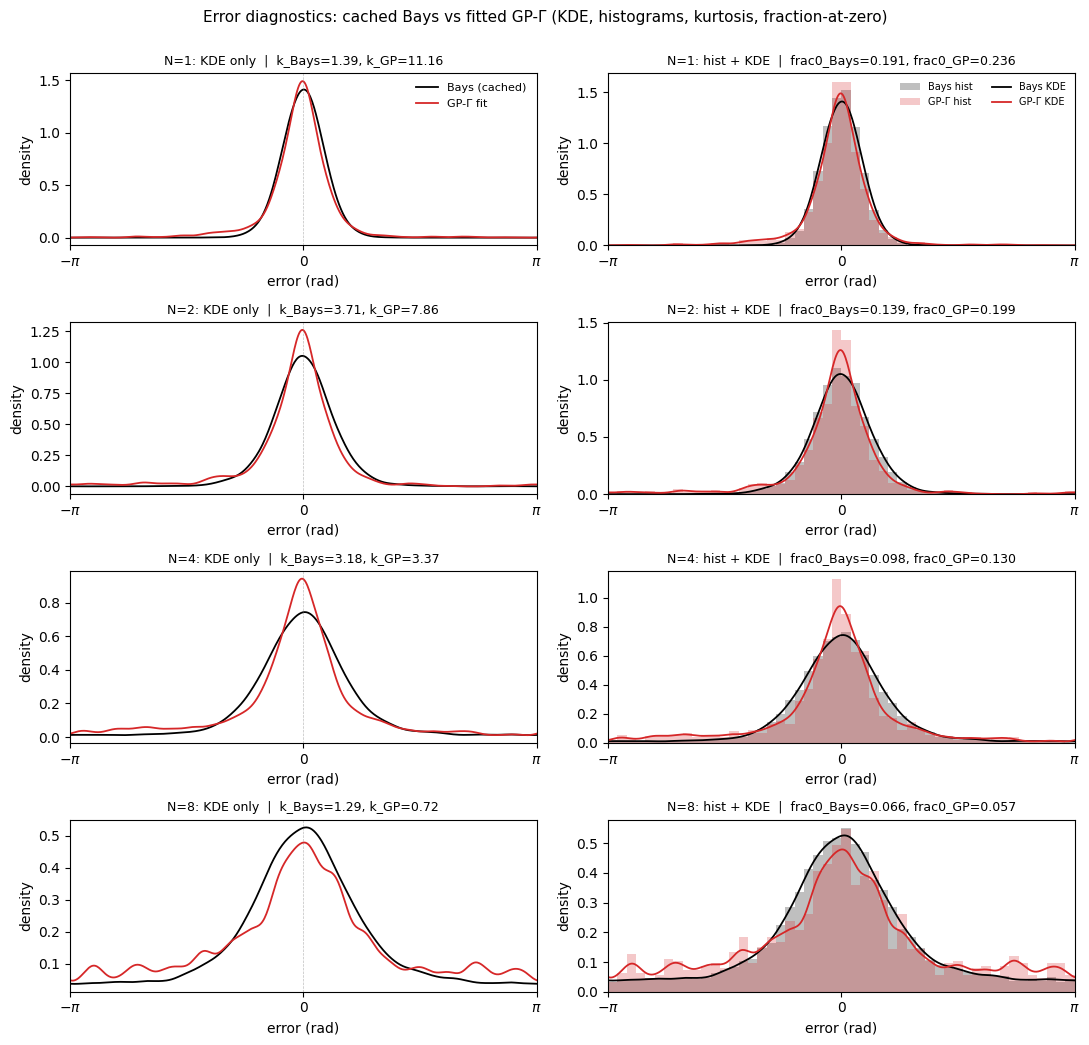


   N |    k_Bays      k_GP |  frac0_Bays    frac0_GP
------------------------------------------------------------------------------
   1 |     1.394    11.159 |      0.1905      0.2360
   2 |     3.709     7.855 |      0.1385      0.1990
   4 |     3.178     3.371 |      0.0975      0.1300
   8 |     1.286     0.724 |      0.0662      0.0570


In [ ]:
# === Diagnostic 2: Isolate errors per set size, KDE + histogram, fraction-at-zero ===
# For each set size in SET_SIZES we:
#   1. Pull the two error arrays (cached Bays, fitted GP-Gamma)
#   2. Print summary stats incl. circular kurtosis (Fisher) and fraction-at-zero
#   3. Apply von Mises KDE to both arrays
#   4. Plot KDE overlay AND histogram-with-KDE in a 2-column-per-set-size figure
#
# "Fraction-at-zero" is operationalised as the fraction of trials whose error
# falls inside the central bin of width 2*EPS_ZERO around 0. With EPS_ZERO=π/N_BINS
# this is just "fraction of trials in the central histogram bin".

# Pick which set size to inspect interactively. Change this to dig into any
# single condition; the loop below covers all of them regardless.
INSPECT_N = 1
EPS_ZERO  = np.pi / 50   # half-width of "at-zero" bin (= one of 50 bins)
KAPPA_KDE = 80.0         # KDE smoothing — see the dedicated sweep cell below

print('=' * 78)
print(f'Per-set-size diagnostic | KDE κ = {KAPPA_KDE} | '
      f'zero-bin half-width = {EPS_ZERO:.4f} rad')
print('=' * 78)

theta_eval = np.linspace(-np.pi, np.pi, 500)
diagnostic_summary = {}

for N in SET_SIZES:
    e_bays = bays_cached_errors[N]
    e_gp   = fitted_errors_gamma[N]

    m_bays = circular_moments(e_bays)
    m_gp   = circular_moments(e_gp)

    frac_zero_bays = np.mean(np.abs(e_bays) < EPS_ZERO)
    frac_zero_gp   = np.mean(np.abs(e_gp)   < EPS_ZERO)

    print(f'\n--- N = {N} ---')
    print(f'  Bays errors:  shape={e_bays.shape}, '
          f'first 8 = {np.array2string(e_bays[:8], precision=3)}')
    print(f'  GP-Γ errors:  shape={e_gp.shape}, '
          f'first 8 = {np.array2string(e_gp[:8],   precision=3)}')
    print(f'  Bays:  circ_var = {m_bays["variance"]:.4f}   '
          f'circ_kurt (Fisher) = {m_bays["kurtosis"]:>7.3f}   '
          f'frac(|err|<{EPS_ZERO:.3f}) = {frac_zero_bays:.4f}')
    print(f'  GP-Γ:  circ_var = {m_gp["variance"]:.4f}   '
          f'circ_kurt (Fisher) = {m_gp["kurtosis"]:>7.3f}   '
          f'frac(|err|<{EPS_ZERO:.3f}) = {frac_zero_gp:.4f}')

    diagnostic_summary[N] = {
        'bays_errors':    e_bays,
        'gp_errors':      e_gp,
        'bays_kurt':      m_bays['kurtosis'],
        'gp_kurt':        m_gp['kurtosis'],
        'bays_frac_zero': frac_zero_bays,
        'gp_frac_zero':   frac_zero_gp,
    }

# --- Figure: one row per set size, [KDE overlay | histogram + KDE] ---
n_rows = len(SET_SIZES)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.6 * n_rows),
                         squeeze=False)

for r, N in enumerate(SET_SIZES):
    e_bays = bays_cached_errors[N]
    e_gp   = fitted_errors_gamma[N]
    kde_bays = vonmises_kde(e_bays, theta_eval, kappa=KAPPA_KDE)
    kde_gp   = vonmises_kde(e_gp,   theta_eval, kappa=KAPPA_KDE)

    # Column 0: KDE overlay, no histogram (clean view of density shape)
    ax = axes[r, 0]
    ax.plot(theta_eval, kde_bays, color='black',   lw=1.3, label='Bays (cached)')
    ax.plot(theta_eval, kde_gp,   color='#D62728', lw=1.3, label='GP-Γ fit')
    ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error (rad)')
    ax.set_ylabel('density')
    ax.set_title(
        f'N={N}: KDE only  |  '
        f'k_Bays={diagnostic_summary[N]["bays_kurt"]:.2f}, '
        f'k_GP={diagnostic_summary[N]["gp_kurt"]:.2f}',
        fontsize=9)
    if r == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=8)

    # Column 1: histogram + KDE for each model, side by side via alpha
    ax = axes[r, 1]
    bins = np.linspace(-np.pi, np.pi, 51)
    ax.hist(e_bays, bins=bins, density=True, color='black',
            alpha=0.25, label='Bays hist')
    ax.hist(e_gp,   bins=bins, density=True, color='#D62728',
            alpha=0.25, label='GP-Γ hist')
    ax.plot(theta_eval, kde_bays, color='black',   lw=1.3, label='Bays KDE')
    ax.plot(theta_eval, kde_gp,   color='#D62728', lw=1.3, label='GP-Γ KDE')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error (rad)')
    ax.set_ylabel('density')
    ax.set_title(
        f'N={N}: hist + KDE  |  '
        f'frac0_Bays={diagnostic_summary[N]["bays_frac_zero"]:.3f}, '
        f'frac0_GP={diagnostic_summary[N]["gp_frac_zero"]:.3f}',
        fontsize=9)
    if r == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=7, ncol=2)

fig.suptitle('Error diagnostics: cached Bays vs fitted GP-Γ '
             '(KDE, histograms, kurtosis, fraction-at-zero)',
             fontsize=11, y=1.00)
fig.tight_layout()
plt.show()

# --- Brief summary table at the end ---
print('\n' + '=' * 78)
print(f'{"N":>4} | {"k_Bays":>9} {"k_GP":>9} | '
      f'{"frac0_Bays":>11} {"frac0_GP":>11}')
print('-' * 78)
for N in SET_SIZES:
    d = diagnostic_summary[N]
    print(f'{N:>4} | {d["bays_kurt"]:>9.3f} {d["gp_kurt"]:>9.3f} | '
          f'{d["bays_frac_zero"]:>11.4f} {d["gp_frac_zero"]:>11.4f}')


KDE κ sweep at N=1
  Bays trials: 10000,  GP-Γ trials: 1000
  (Kurtosis is computed from raw samples, so it does not change with κ.)

  circ kurt (Bays) = 1.394
  circ kurt (GP-Γ) = 11.159



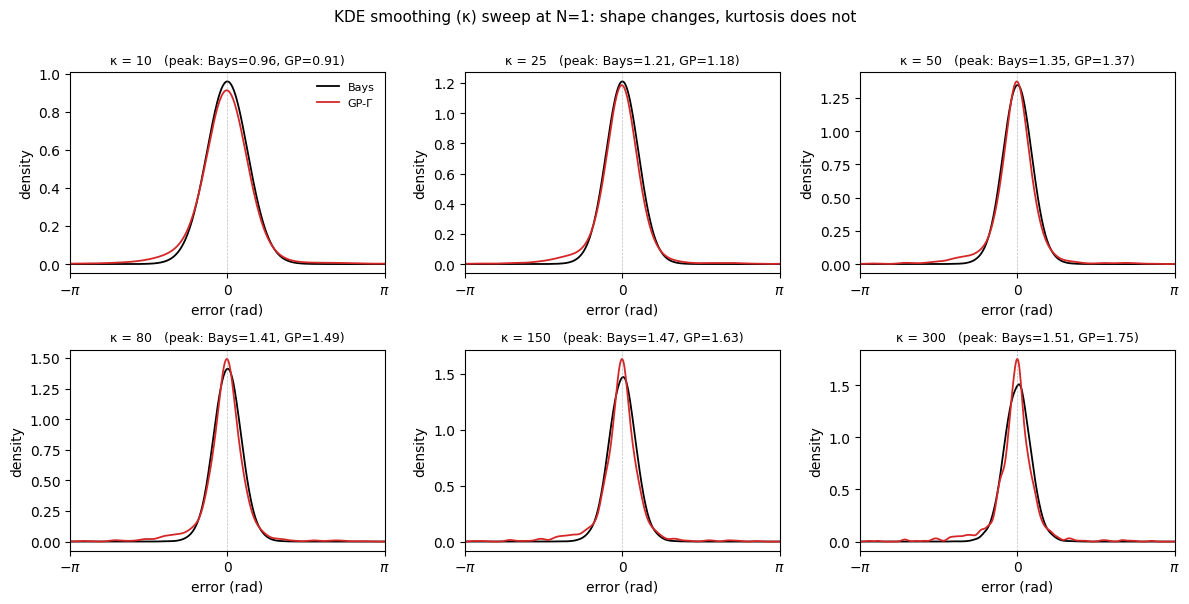


Peak density vs κ (this is purely a smoothing artefact, not data):
         κ   peak_Bays     peak_GP   ratio_GP/Bays
  --------------------------------------------------
      10.0       0.958       0.912           0.951
      25.0       1.210       1.185           0.980
      50.0       1.347       1.374           1.020
      80.0       1.412       1.492           1.056
     150.0       1.469       1.630           1.110
     300.0       1.509       1.752           1.161

Guidance for picking κ:
  • κ ≈ 25     : matches the GP-figure default (panels a/c) — broad smoothing
  • κ ≈ 44     : matches the GP-figure panel-e default — moderate
  • κ ≈ 80     : matches the Bays-figure default (KAPPA_BAYS_AC)
  • κ ≳ 200    : near-raw histogram view, lots of wiggle at low set sizes
  Pick the smallest κ that still resolves the feature you are trying to see.


In [ ]:
# === Diagnostic 3: KDE smoothing (κ) hyperparameter sweep ===
# The von Mises KDE used everywhere above has a single tunable knob: κ.
#   high κ  →  narrow kernel  →  less smoothing  →  more wiggle, more peakiness
#   low  κ  →  wide kernel    →  more smoothing  →  flatter, less peakiness
#
# Because circular kurtosis is computed from the raw samples (not the KDE),
# the numbers k_Bays and k_GP do NOT change with κ. What changes is the
# VISUAL impression of how sharp / flat the densities are, which matters when
# you're eyeballing whether the GP fit "matches the peak" of Bays.
#
# This cell sweeps κ ∈ {10, 25, 50, 80, 150, 300} and overlays the resulting
# Bays vs GP-Γ KDEs at one chosen set size so you can see what each setting
# does. Change SWEEP_N to inspect a different set size.

SWEEP_N = 1
KAPPA_SWEEP = [10.0, 25.0, 50.0, 80.0, 150.0, 300.0]

e_bays_s = bays_cached_errors[SWEEP_N]
e_gp_s   = fitted_errors_gamma[SWEEP_N]

print(f'KDE κ sweep at N={SWEEP_N}')
print(f'  Bays trials: {len(e_bays_s)},  GP-Γ trials: {len(e_gp_s)}')
print(f'  (Kurtosis is computed from raw samples, so it does not change '
      f'with κ.)\n')

# Show that kurtosis is κ-invariant by listing it once
k_bays_s = circular_kurtosis_bays(e_bays_s)
k_gp_s   = circular_kurtosis_bays(e_gp_s)
print(f'  circ kurt (Bays) = {k_bays_s:.3f}')
print(f'  circ kurt (GP-Γ) = {k_gp_s:.3f}\n')

theta_eval = np.linspace(-np.pi, np.pi, 500)
n_panels = len(KAPPA_SWEEP)
ncols = 3
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.0 * nrows),
                         squeeze=False)

# Per-panel peak heights so you can see how κ inflates the apparent peak
peak_heights = []
for i, kappa in enumerate(KAPPA_SWEEP):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    kde_b = vonmises_kde(e_bays_s, theta_eval, kappa=kappa)
    kde_g = vonmises_kde(e_gp_s,   theta_eval, kappa=kappa)
    peak_heights.append((kappa, kde_b.max(), kde_g.max()))

    ax.plot(theta_eval, kde_b, color='black',   lw=1.3, label='Bays')
    ax.plot(theta_eval, kde_g, color='#D62728', lw=1.3, label='GP-Γ')
    ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error (rad)')
    ax.set_ylabel('density')
    ax.set_title(f'κ = {kappa:g}   '
                 f'(peak: Bays={kde_b.max():.2f}, GP={kde_g.max():.2f})',
                 fontsize=9)
    if i == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=8)

# Hide unused subplots
for j in range(n_panels, nrows * ncols):
    axes[j // ncols, j % ncols].axis('off')

fig.suptitle(f'KDE smoothing (κ) sweep at N={SWEEP_N}: '
             f'shape changes, kurtosis does not',
             fontsize=11, y=1.00)
fig.tight_layout()
plt.show()

# --- Numerical summary: peak height vs κ ---
print('\nPeak density vs κ (this is purely a smoothing artefact, not data):')
print(f'  {"κ":>8}  {"peak_Bays":>10}  {"peak_GP":>10}  {"ratio_GP/Bays":>14}')
print('  ' + '-' * 50)
for kappa, pb, pg in peak_heights:
    print(f'  {kappa:>8.1f}  {pb:>10.3f}  {pg:>10.3f}  {pg/pb:>14.3f}')

print(
    '\nGuidance for picking κ:\n'
    '  • κ ≈ 25     : matches the GP-figure default (panels a/c) — broad smoothing\n'
    '  • κ ≈ 44     : matches the GP-figure panel-e default — moderate\n'
    '  • κ ≈ 80     : matches the Bays-figure default (KAPPA_BAYS_AC)\n'
    '  • κ ≳ 200    : near-raw histogram view, lots of wiggle at low set sizes\n'
    '  Pick the smallest κ that still resolves the feature you are trying to see.'
)


### Diagnostic — GP Forward at the Bays Truth


In [ ]:
# === GP forward at Bays-truth parameters ===
# If N=1 kurtosis comes in near Bays's reference, the fit is the issue.
# If it stays high, the GP is structurally different from Bays at N=1.

# This diagnostic uses the global M (and the global GP_SAMPLER's Gamma
# variant for the near-homogeneous test). It is independent of the
# experiment-cell overrides above.
_M_local = M
SEED_FIT = globals().get('SEED_FIT', SEED)
N_TRIALS_FIT = globals().get('N_TRIALS_FIT', 1000)
GAIN_VARIABILITY = globals().get('GAIN_VARIABILITY', 0.0)

max_locs = max(SET_SIZES)
population_truth = generate_neuron_population(
    n_neurons=_M_local, n_orientations=N_THETA, n_locations=max_locs,
    base_lengthscale=np.sqrt(OMEGA_BAYS),
    lengthscale_variability=0.01,        # essentially homogeneous
    seed=SEED_FIT,
    gain_variability=GAIN_VARIABILITY,
    method='gamma',
)
thetas_t = population_truth[0]['orientations']
f_all_t  = [np.array([population_truth[n]['f_samples'][loc, :] for n in range(_M_local)])
            for loc in range(max_locs)]

print(f'GP at Bays truth: M={_M_local}, omega={OMEGA_BAYS}, '
      f'gamma_total={GAMMA_TOTAL_BAYS}, CV=0.01\n')
print(f'{"N":>3}  {"var_GP":>10}  {"kurt_GP":>11}  '
      f'{"var_Bays":>10}  {"kurt_Bays":>11}')
print('-' * 60)
for N in SET_SIZES:
    rng = np.random.RandomState(SEED_FIT + 99000 + N)
    errs = run_multiloc_trials(
        f_all_t, thetas_t, tuple(range(N)), 0,
        GAMMA_TOTAL_BAYS / _M_local, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    m_t = circular_moments(errs)
    m_b = circular_moments(bays_cached_errors[N])
    print(f'{N:>3}  {m_t["variance"]:>10.4f}  {m_t["kurtosis"]:>11.3f}  '
          f'{m_b["variance"]:>10.4f}  {m_b["kurtosis"]:>11.3f}')


GP at Bays truth: M=100, omega=0.52, gamma_total=119.0, CV=0.01

  N      var_GP      kurt_GP    var_Bays    kurt_Bays
------------------------------------------------------------
  1      0.2289       14.590      0.0734        1.394
  2      0.4060        8.660      0.1770        3.709
  4      0.5966        4.873      0.4577        3.178
  8      1.0745        2.153      1.0153        1.286


### Diagnostic — M-Scaling at the Bays Truth


In [ ]:
# === M-scaling diagnostic at Bays-truth parameters ===
# Defensive bindings: this diagnostic stands alone, so make sure
# the names it uses are defined even if the fit cells weren't run.
SEED_FIT = globals().get('SEED_FIT', SEED)
N_TRIALS_FIT = globals().get('N_TRIALS_FIT', 1000)
GAIN_VARIABILITY = globals().get('GAIN_VARIABILITY', 0.0)

M_VALUES_TEST = [100, 1000]    # Add 10000 if the cache exists and time permits

print('=' * 78)
print('GP at Bays truth (omega=0.52, gamma_total=119, CV=0.01) — M sweep')
print('=' * 78)
print(f'(GP trials per condition: {N_TRIALS_FIT}; '
      f'Bays cached trials: {len(bays_cached_errors[1])})\n')

bays_summary_diag = {N: circular_moments(bays_cached_errors[N]) for N in SET_SIZES}

print(f'{"M":>6}  {"N":>3}  '
      f'{"var_GP":>9}  {"var_Bays":>10}  {"Δvar":>9}  '
      f'{"kurt_GP":>9}  {"kurt_Bays":>11}  {"Δkurt":>9}')
print('-' * 78)

m_sweep_results = {}
for M_test in M_VALUES_TEST:
    t0 = time.time()
    max_locs = max(SET_SIZES)
    population_M = generate_neuron_population(
        n_neurons=M_test, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=np.sqrt(OMEGA_BAYS),
        lengthscale_variability=0.01,
        seed=SEED_FIT,
        gain_variability=GAIN_VARIABILITY,
        method='gamma',
    )
    thetas_M = population_M[0]['orientations']
    f_all_M  = [np.array([population_M[n]['f_samples'][loc, :] for n in range(M_test)])
                for loc in range(max_locs)]
    gamma_per_neuron = GAMMA_TOTAL_BAYS / M_test

    M_results = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED_FIT + 99000 + N + M_test * 7)
        errs = run_multiloc_trials(
            f_all_M, thetas_M, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        m = circular_moments(errs)
        M_results[N] = {'errors': errs, **m}
        b = bays_summary_diag[N]
        print(f'{M_test:>6}  {N:>3}  '
              f'{m["variance"]:>9.4f}  {b["variance"]:>10.4f}  '
              f'{m["variance"] - b["variance"]:>+9.4f}  '
              f'{m["kurtosis"]:>9.3f}  {b["kurtosis"]:>11.3f}  '
              f'{m["kurtosis"] - b["kurtosis"]:>+9.3f}')
    m_sweep_results[M_test] = M_results
    print(f'{" "*6}  {" "*3}  (built+ran in {time.time()-t0:.1f}s)\n')

print('=' * 78)
print('Verdict at N=1:')
print('=' * 78)
k_bays_N1 = bays_summary_diag[1]['kurtosis']
print(f'  Bays (cache, M={M}):    kurt = {k_bays_N1:>6.2f}')
for M_test, M_res in m_sweep_results.items():
    k = M_res[1]['kurtosis']
    print(f'  GP, M={M_test:>5}:           kurt = {k:>6.2f}    '
          f'(Δ = {k - k_bays_N1:+.2f})')


GP at Bays truth (omega=0.52, gamma_total=119, CV=0.01) — M sweep
(GP trials per condition: 1000; Bays cached trials: 10000)

     M    N     var_GP    var_Bays       Δvar    kurt_GP    kurt_Bays      Δkurt
------------------------------------------------------------------------------
   100    1     0.2350      0.0734    +0.1616     14.921        1.394    +13.527
   100    2     0.3627      0.1770    +0.1857      8.636        3.709     +4.927
   100    4     0.7133      0.4577    +0.2556      4.146        3.178     +0.968
   100    8     1.2515      1.0153    +0.2362      1.672        1.286     +0.385
             (built+ran in 2.4s)

  1000    1     0.1269      0.0734    +0.0534     22.201        1.394    +20.807
  1000    2     0.1599      0.1770    -0.0171     19.222        3.709    +15.514
  1000    4     0.3028      0.4577    -0.1548     10.314        3.178     +7.136
  1000    8     0.6756      1.0153    -0.3398      3.878        1.286     +2.592
             (built+ran in 16.9s

## Run Summary


In [ ]:
print('=' * 70)
print(f'Figure 2 run complete')
print('=' * 70)
print(f'Global M           = {M}')
print(f'Global GP_SAMPLER  = {GP_SAMPLER!r}')
print(f'Global OUTPUT_DIR  = {OUTPUT_DIR}')
print()

# Each main experiment has its own output directory; list whichever exist.
if 'FIT_OUTPUT_DIR' in globals():
    print(f'GP-to-Bays Fit  (M={M_FIT}, dist={DISTRIBUTION_FIT}):')
    print(f'  {FIT_OUTPUT_DIR}')
    for p in sorted(FIT_OUTPUT_DIR.glob('*')):
        if p.is_file():
            print(f'    {p.name}')
    print()

if 'SWEEP_OUTPUT_DIR' in globals():
    print(f'Fixed-CV Sweep  (M={M_SWEEP}, dist={DISTRIBUTION_SWEEP}):')
    print(f'  {SWEEP_OUTPUT_DIR}')
    for p in sorted(SWEEP_OUTPUT_DIR.rglob('*')):
        if p.is_file():
            rel = p.relative_to(SWEEP_OUTPUT_DIR)
            print(f'    {rel}')
    print()

print(f'Other-experiment figures (under global OUTPUT_DIR):')
for p in sorted(OUTPUT_DIR.rglob('*')):
    if p.is_file():
        rel = p.relative_to(OUTPUT_DIR)
        print(f'    {rel}')


Figure 2 run complete
Global M           = 100
Global GP_SAMPLER  = 'folded_normal'
Global OUTPUT_DIR  = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_2_M100_folded_normal_20260602_182225

GP-to-Bays Fit  (M=100, dist=gamma):
  /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/fit_M100_gamma_20260602_182225
    gp_fit_gamma_overlay.pdf
    gp_fit_gamma_overlay.png

Fixed-CV Sweep  (M=100, dist=gamma):
  /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/cv_sweep_M100_20260602_182252
    cv_sweep_variance_kurtosis.pdf
    cv_sweep_variance_kurtosis.png
    gp_cv_0p1_fit.pdf
    gp_cv_0p1_fit.png
    gp_cv_0p5_fit.pdf
    gp_cv_0p5_fit.png
    gp_cv_10p0_fit.pdf
    gp_cv_10p0_fit.png
    gp_cv_1p0_fit.pdf
    gp_cv_1p0_fit.png
    gp_cv_2p0_fit.pdf
    gp_